In [1]:
!pip install -q dm-haiku optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 7.6 MB/s eta 0:00:00


In [2]:
# %%
# Cell 1: Environment Setup & Imports (V17.7-corrected, RUN_MODE-compatible)
#
# Base: the "peer-review response" V17.7 lineage (upwind-fixed Cell 3, full-trajectory Cell 8,
# explicit Adam-vs-L-BFGS comparison) — the lineage validated as Run A in the Kaggle smoke test
# (nu_FD=40, LBFGS_MAX_PHYSICS_POINTS=20000). Run B's manually-edited NU_FD_PHYSICAL=800 line is
# NOT part of this codebase — see the roadmap document for why that run is discarded.
#
# No functional change in this cell for the RUN_MODE extension (Cell 2). Reproduced verbatim
# from the validated lineage.
#
# --- ORIGINAL HEADER (preserved) ---
# V17.7 responds to a structured peer-review pass on V17.6 (proposal + Cells 2-8) and to a
# numpy-only empirical smoke test run in a sandboxed environment. See CHANGELOG_V17_7_CODE.md
# for the itemized record. Headline items: (1) a critical, previously-undetected numerical
# instability in Cell 3's ground-truth generator — confirmed present in the ORIGINAL,
# unmodified V17.6 code — is fixed; (2) Cell 8's headline evaluation metrics, which V17.6
# computed at a near-rest t=0 snapshot, now use the full post-spin-up trajectory; (3) the
# RMSE(Cf)-before/after-L-BFGS comparison promised in §9.4/VB13 is now actually implemented,
# not just described in the proposal text.
import os
import time
import pickle
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.optimize
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# XLA Memory Management for Kaggle T4
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optax
import haiku as hk

jax.config.update("jax_enable_x64", True)
print("✅ JAX 64-bit precision enabled. Environment ready for V17.7-corrected "
      "(peer-review response release + RUN_MODE three-tier extension: smoke/medium/full). "
      "Ground-truth generator uses upwind advection (stable); evaluation is full-trajectory "
      "post-spin-up; Adam-vs-L-BFGS RMSE(Cf) comparison runs automatically in Cell 8. "
      "See ROADMAP.md for the execution plan and CHANGELOG_V17_7_CODE.md for why V17.6-or-"
      "earlier results (and any run with NU_FD_PHYSICAL != 40.0) are invalid.")


✅ JAX 64-bit precision enabled. Environment ready for V17.7-corrected (peer-review response release + RUN_MODE three-tier extension: smoke/medium/full). Ground-truth generator uses upwind advection (stable); evaluation is full-trajectory post-spin-up; Adam-vs-L-BFGS RMSE(Cf) comparison runs automatically in Cell 8. See ROADMAP.md for the execution plan and CHANGELOG_V17_7_CODE.md for why V17.6-or-earlier results (and any run with NU_FD_PHYSICAL != 40.0) are invalid.


In [3]:
# %%
# Cell 2: Configuration & Scaling Namespaces (V17.7-corrected + RUN_MODE extension + friction-
# branch saturation fix)
#
# 💥 NEW IN THIS SECOND PATCH (after the first RUN_MODE="medium" three-scenario sweep — see
# ROADMAP.md Step 2b): that sweep rejected the "undertraining alone" hypothesis (VB25) — going
# from smoke's 1500 epochs to medium's 6000 epochs did NOT move r(Cf) up from ~0.42 for the
# wind-ON scenarios; it collapsed r(Cf) to ~0.06 (wind-OFF improved only marginally, to 0.46).
# The training_history telemetry pinpoints a specific mechanism: sigmoid_deriv_mean (how far
# the friction branch's sigmoid output sits from either bound) fell from 0.243 at epoch 50 to
# 0.018 (wind-OFF) / 0.105 (wind-ON) by epoch 6000 — the sigmoid is saturating early and
# freezing Cf's gradient signal, which more epochs then reinforce rather than correct.
# FOURIER_SIGMA_FRIC and ADAM_LR_FRIC below are lowered as a first, minimal diagnostic probe at
# this mechanism (see their inline comments). This is NOT yet confirmed to fix the problem —
# it is the next single-change experiment the roadmap calls for before any FULL-tier run.
#
# --- FIRST PATCH HEADER (preserved) ---
# 💥 NEW IN THAT PATCH: the old binary `SMOKE_TEST = True/False` switch is replaced by a
# three-tier `RUN_MODE` switch: "smoke" | "medium" | "full". This is a BACKWARD-COMPATIBLE
# extension, not a rewrite:
#   - `config.SMOKE_TEST` still exists as a derived boolean (True only when RUN_MODE=="smoke"),
#     so every downstream cell (3/6/7/8) that reads `config.SMOKE_TEST` for messaging keeps
#     working unmodified.
#   - "smoke" behaves EXACTLY as before (1500 epochs, 3-day dataset) — nothing about the
#     original pipeline-health check was removed.
#   - "full" behaves EXACTLY as before (32000 epochs, 8-day dataset) — nothing about the
#     original full-run tier was removed.
#   - "medium" is NEW: 6000 epochs, but reuses the SAME 3-day dataset as "smoke" (Cell 3 is
#     NOT re-run for this tier). Rationale: isolate "does more training budget help?" as its
#     own question from "does more data help?" — see ROADMAP.md Step 1/2. Existing Adam/L-BFGS/
#     evaluation code needs zero changes to support this tier; only the epoch budget differs.
#   - `config.mode_label()` gives a three-way-correct display string (used in Cells 6/7/8
#     instead of the old two-way `'SMOKE TEST' if SMOKE_TEST else 'FULL RUN'` ternary, which
#     would have mislabeled "medium" as "FULL RUN").
#   - `config.run_id()` now derives its filename suffix from RUN_MODE ("_smoketest" / "_medium"
#     / "") instead of from the SMOKE_TEST boolean directly — so smoke, medium, and full runs
#     of the same ablation scenario never collide on disk.
#
# 💥 ALSO NEW: `LBFGS_MAXITER` / `LBFGS_FTOL` / `LBFGS_GTOL` are promoted from hardcoded
# literals inside Cell 7's `scipy.optimize.minimize(...)` call to config values, and Cell 7 now
# prints `res.nit` / `res.nfev` / `res.message` after every L-BFGS-B run. Motivation: the Run A
# Kaggle smoke test spent 18249s (~5.1h) on L-BFGS-B against only 175s for the entire Adam phase
# (~104x), with NO visibility into whether that time was `maxiter` exhaustion or many function
# evaluations inside the line search. Defaults below are loosened relative to the original
# (maxiter 10000→1000, ftol 1e-12→1e-10, gtol 1e-7→1e-6) for the "smoke"/"medium" diagnostic
# tiers; tighten them back for the "full" tier once Cell 7's new nit/nfev telemetry tells you
# what convergence actually looks like on this problem (see ROADMAP.md Step 4).
#
# --- ORIGINAL RECONCILIATION NOTES (Series A vs. Series B), preserved for history ---
#   1. SAT_TRACK_DRIFT_KM_PER_SNAPSHOT — standardized to 1.7 (Series B's value); see Cell 3.
#   2. ENABLE_DECOUPLED_COLLOCATION — Series A's mechanism, retained (default True).
#   3. PHYSICS_COLLOCATION_BATCH_SIZE — naming from Series B.
#   4. LBFGS_MAX_DATA_POINTS / LBFGS_MAX_PHYSICS_POINTS — promoted to config from Series B;
#      NOT required to be equal (Cell 7's modulo-wrapped chunking handles unequal sizes).
#   5. NU_FD_PHYSICAL — promoted to config from Series B. AUTHORITATIVE VALUE IS 40.0 m^2/s,
#      confirmed by the proposal's V17.4 reconciliation footnote. Do NOT hand-edit this to any
#      other value (the discarded Run B notebook set it to 800.0, which artificially damps the
#      generated dynamics 20x beyond the documented physics and is not a valid twin experiment
#      — see ROADMAP.md).
#   6. RESET_FRICTION_OPTIMIZER_AT_PHASE2 — identical in both series; unchanged here.
class config:
    G_REAL = 9.81
    L_REF = 100_000.0
    H_REF = 100.0

    C_WAVE = np.sqrt(G_REAL * H_REF)
    TIME_SCALE_TAU = L_REF / C_WAVE

    # V17 §9.1: Two-Branch Architecture (unchanged since V17.0)
    NN_HYDRO_LAYERS = [3, 128, 128, 128, 128, 3]   # Inputs: (t,x,y) -> Outputs: (h,u,v)
    NN_FRIC_LAYERS = [2, 128, 128, 128, 1]         # Inputs: (x,y)   -> Outputs: (Cf_raw)
    NN_ACTIVATION = 'tanh'

    FOURIER_SIGMA = 1.0
    # 💥 CHANGED IN THIS PATCH (diagnosed from the RUN_MODE="medium" three-scenario sweep — see
    # ROADMAP.md Step 2b): sigmoid_deriv_mean collapsed from 0.243 (epoch 50) to 0.018
    # (wind_off_diff_off) / 0.105 (wind_on_*) by epoch 6000 — the friction branch's sigmoid
    # output saturated toward one of its bounds early and stayed there, which freezes the
    # gradient signal Cf receives and is consistent with why MORE training made the wind-ON
    # scenarios' r(Cf) collapse (0.42 -> 0.061) instead of improving. FOURIER_SIGMA_FRIC controls
    # the initial variance of the random Fourier features feeding the friction branch's final
    # linear layer; a large value (3.0, V17.4's original choice) produces large pre-sigmoid
    # logits from initialization, which pushes the sigmoid toward saturation almost immediately.
    # Lowered to 1.5 as a first, minimal, single-variable diagnostic change — re-run
    # RUN_MODE="medium" and check whether sigmoid_deriv_mean stays above ~0.15 by epoch 6000
    # before concluding this fixes it (see ROADMAP.md Step 2b for the exact check).
    FOURIER_SIGMA_FRIC = 1.5  # was 3.0 (V17.4 finding S2) — lowered to reduce early sigmoid saturation

    # ═══════════════════════════════════════════════════════════════════════════════
    # SINGLE SWITCH (now three-tier). Change ONLY this one line to move between tiers.
    # T_MAX_PHYSICAL / DATA_PATH / EPOCHS_ADAM / PHASE1_EPOCHS / WARM_TRANSITION_EPOCHS all
    # follow automatically. Do not edit any other cell to switch tiers.
    # ═══════════════════════════════════════════════════════════════════════════════
    RUN_MODE = "medium"   # "smoke" | "medium" | "full"
    assert RUN_MODE in ("smoke", "medium", "full"), f"Invalid RUN_MODE: {RUN_MODE!r}"

    # Backward-compatible derived flag — True ONLY for "smoke". Every existing `if
    # config.SMOKE_TEST:` check elsewhere in the codebase keeps meaning exactly what it meant
    # before this patch: "this is the original, tiny pipeline-health-check tier."
    SMOKE_TEST = (RUN_MODE == "medium")

    # --- Twin-experiment duration (physical seconds) ---
    T_MAX_PHYSICAL_FULL = 8.0 * 24.0 * 3600.0        # 8 days
    T_MAX_PHYSICAL_SMOKETEST = 3.0 * 24.0 * 3600.0   # 3 days — shared by "smoke" AND "medium"
    T_MAX_PHYSICAL = T_MAX_PHYSICAL_FULL if RUN_MODE == "full" else T_MAX_PHYSICAL_SMOKETEST
    T_MAX_NORM = T_MAX_PHYSICAL / TIME_SCALE_TAU
    CAUSAL_EPSILON = 3.0 / T_MAX_NORM

    ADAM_LR_HYDRO = 1e-3
    # 💥 CHANGED IN THIS PATCH (same diagnosis as FOURIER_SIGMA_FRIC above): a lower peak
    # learning rate for the friction branch gives the sigmoid fewer large early steps to
    # saturate on before the loss landscape around Cf has been explored. Halved from the
    # original value as a conservative first try, alongside the FOURIER_SIGMA_FRIC change —
    # changing both at once means a re-run cannot cleanly attribute improvement to one or the
    # other, but given compute cost, a single combined "does saturation resolve at all" probe
    # is a reasonable first step; isolate the two afterward only if the combined change works
    # and you need to know which one to keep for the 'full' tier.
    ADAM_LR_FRIC = 5e-5  # was 1e-4 — lowered alongside FOURIER_SIGMA_FRIC to reduce early sigmoid saturation
    BASE_SEED = 42

    # --- Training budget: full-run values (unchanged) ---
    EPOCHS_ADAM_FULL = 32000
    PHASE1_EPOCHS_FULL = 13300
    WARM_TRANSITION_EPOCHS_FULL = 500

    # --- Training budget: smoke-test values (unchanged) ---
    EPOCHS_ADAM_SMOKETEST = 1500
    PHASE1_EPOCHS_SMOKETEST = 600
    WARM_TRANSITION_EPOCHS_SMOKETEST = 50

    # --- Training budget: NEW medium-diagnostic values. Same ~42%/~1.7% phase-timing ratios
    # as the smoke/full tiers, so Phase 1 -> Phase 2 -> warm-transition behaves consistently
    # across tiers. At 6000 epochs, physics-pool effective passes rise from ~4.2 (smoke) to
    # ~17 (medium) — close to the REFERENCE_MIN_PASSES=20 floor Cell 6 already checks against,
    # for a fraction of the full tier's cost. ---
    EPOCHS_ADAM_MEDIUM = 6000
    PHASE1_EPOCHS_MEDIUM = 2500
    WARM_TRANSITION_EPOCHS_MEDIUM = 100

    _BUDGETS = {
        "smoke":  (EPOCHS_ADAM_SMOKETEST, PHASE1_EPOCHS_SMOKETEST, WARM_TRANSITION_EPOCHS_SMOKETEST),
        "medium": (EPOCHS_ADAM_MEDIUM, PHASE1_EPOCHS_MEDIUM, WARM_TRANSITION_EPOCHS_MEDIUM),
        "full":   (EPOCHS_ADAM_FULL, PHASE1_EPOCHS_FULL, WARM_TRANSITION_EPOCHS_FULL),
    }
    EPOCHS_ADAM, PHASE1_EPOCHS, WARM_TRANSITION_EPOCHS = _BUDGETS[RUN_MODE]

    LOSS_LOG_INTERVAL = 50

    RESET_FRICTION_OPTIMIZER_AT_PHASE2 = True

    # --- Wind Forcing Parameters ---
    RHO_WATER = 1025.0
    WIND_STRESS_MAX = 0.5  # N/m^2
    WIND_PERIOD_PHYSICAL = 4.0 * 24.0 * 3600.0
    # V17.7: 90° phase offset between tau_x/tau_y so the synthetic wind vector rotates rather
    # than only oscillating in magnitude. Stylized proxy, not real wind-direction statistics.
    WIND_ROTATION_PHASE_RAD = np.pi / 2.0

    SPINUP_DURATION_PHYSICAL = 12.0 * 3600.0
    SAVE_INTERVAL_STEPS = 3600  # dt=1s -> hourly snapshots

    MIN_WIND_TIDE_PERIOD_RATIO = 3.0

    # --- Satellite ground-track sparsification ---
    ENABLE_SATELLITE_SPARSIFICATION = True
    SAT_N_TRACKS = 4
    SAT_TRACK_ANGLE_DEG = 80.0
    SAT_TRACK_HALF_WIDTH_KM = 2.0
    SAT_TRACK_DRIFT_KM_PER_SNAPSHOT = 1.7

    ENABLE_DECOUPLED_COLLOCATION = True
    PHYSICS_COLLOCATION_BATCH_SIZE = 1000

    # V17 §9.1: Bounded sigmoid transform for Cf
    CF_MIN = 0.0015
    CF_RANGE = 0.0065   # -> Cf in [0.0015, 0.0080]

    EPS_NORM = 0.1 / H_REF

    HUBER_DELTA = 0.05
    LAMBDA_TV = 1e-6

    NU_BASE_PHYSICAL = 2.0
    NU_MAX_PHYSICAL = 20.0
    NU_TRANSITION_K = 5.0

    # ⚠️ AUTHORITATIVE VALUE: 40.0 m^2/s. See header note #5 above — do not hand-edit.
    NU_FD_PHYSICAL = 40.0

    # V17 §8.1: Twin-experiment ablation toggles — set per scenario by Cell 9's driver loop,
    # or by hand for a single scenario.
    ENABLE_WIND = True
    ENABLE_DIFFUSION = True

    LBFGS_MAX_DATA_POINTS = 5000
    LBFGS_MAX_PHYSICS_POINTS = 20000
    LBFGS_CHUNK_SIZE = 500

    # 💥 NEW (this patch): promoted from Cell 7's hardcoded `options={...}` dict to config, so
    # the smoke/medium diagnostic tiers can run cheaply and full's final numbers can use
    # stricter tolerances once Cell 7's nit/nfev telemetry tells you what's actually needed.
    # Loosened from the original V17.7 values (maxiter 10000, ftol 1e-12, gtol 1e-7).
    LBFGS_MAXITER = 1000
    LBFGS_FTOL = 1e-10
    LBFGS_GTOL = 1e-6

    EVALUATE_ADAM_STAGE_SEPARATELY = True

    @staticmethod
    def scenario_tag():
        """Encodes the ablation case (ENABLE_WIND/ENABLE_DIFFUSION) into a filename-safe tag,
        e.g. 'wind_on_diff_off'. Does NOT encode RUN_MODE — see run_id() for that."""
        w = "on" if config.ENABLE_WIND else "off"
        d = "on" if config.ENABLE_DIFFUSION else "off"
        return f"wind_{w}_diff_{d}"

    # 💥 NEW: RUN_MODE -> filename-suffix map, used by run_id(). "full" keeps the original
    # empty suffix so full-run file paths are byte-identical to pre-patch V17.7 — nothing
    # about the full-run naming convention changed.
    _RUN_MODE_SUFFIX = {"smoke": "_smoketest", "medium": "_medium", "full": ""}

    @staticmethod
    def run_id():
        """scenario_tag() + a RUN_MODE-derived suffix. ALL file I/O (weights, training
        history, per-scenario results) in Cells 6/7/8 keys off THIS, not scenario_tag() alone
        — so smoke, medium, and full runs of the same scenario never collide on disk."""
        return f"{config.scenario_tag()}{config._RUN_MODE_SUFFIX[config.RUN_MODE]}"

    @staticmethod
    def mode_label():
        """💥 NEW: three-way-correct display string for print statements in Cells 6/7/8,
        replacing the old two-way `'SMOKE TEST' if SMOKE_TEST else 'FULL RUN'` ternary (which
        would have mislabeled the new "medium" tier as "FULL RUN")."""
        return {"smoke": "🧪 SMOKE TEST", "medium": "🩺 MEDIUM DIAGNOSTIC", "full": "🚀 FULL RUN"}[config.RUN_MODE]

    # Resolved once at class-definition time. "medium" intentionally shares "smoke"'s dataset.
    DATA_PATH = ('data/twin_experiment_v17.npz' if RUN_MODE == "full"
                 else 'data/twin_experiment_v17_smoketest.npz')


class utils_scaling:
    G_STAR = (config.G_REAL * config.H_REF * (config.TIME_SCALE_TAU**2)) / (config.L_REF**2)
    FRICTION_SCALE = config.L_REF / config.H_REF
    WIND_SCALE = (config.TIME_SCALE_TAU**2) / (config.RHO_WATER * config.L_REF * config.H_REF)
    NU_SCALE = config.TIME_SCALE_TAU / (config.L_REF**2)
    NU_BASE_SCALED = config.NU_BASE_PHYSICAL * NU_SCALE
    NU_MAX_SCALED = config.NU_MAX_PHYSICAL * NU_SCALE

    @staticmethod
    def normalize_spatial(x_real, y_real):
        return x_real / config.L_REF, y_real / config.L_REF

    @staticmethod
    def normalize_temporal(t_real):
        return t_real / config.TIME_SCALE_TAU

    @staticmethod
    def normalize_kinematics(h_real, u_real, v_real):
        h_star = h_real / config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_star = u_real / v_scale
        v_star = v_real / v_scale
        return h_star, u_star, v_star

    @staticmethod
    def denormalize_outputs(h_star, u_star, v_star, Cf_star):
        h_real = h_star * config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_real = u_star * v_scale
        v_real = v_star * v_scale
        return h_real, u_real, v_real, Cf_star


_T_TIDAL_M2_REF = 12.42 * 3600.0
_period_ratio_preview = config.WIND_PERIOD_PHYSICAL / _T_TIDAL_M2_REF

print(f"✅ Configuration locked — RUN_MODE = {config.RUN_MODE!r} ({config.mode_label()}) | "
      f"DATA_PATH = {config.DATA_PATH}")
print(f"    Twin-experiment duration: T_MAX_PHYSICAL = {config.T_MAX_PHYSICAL/86400:.2f} days")
print(f"    Wind period: {config.WIND_PERIOD_PHYSICAL/3600:.1f}h "
      f"(~{_period_ratio_preview:.2f}x the M2 tidal period, minimum required ratio: "
      f"{config.MIN_WIND_TIDE_PERIOD_RATIO}x) | wind rotation phase offset: "
      f"{np.degrees(config.WIND_ROTATION_PHASE_RAD):.0f}°")
print(f"    Satellite sparsification (DATA term only): "
      f"{'🛰️ ON' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'} "
      f"(drift={config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT} km/snapshot) | Physics-collocation pool: "
      f"{'DECOUPLED, full-domain' if config.ENABLE_DECOUPLED_COLLOCATION else 'COUPLED to satellite mask (comparison mode)'}")
print(f"    Training budget: EPOCHS_ADAM={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
      f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
print(f"    nu_FD (Cell 3 ground-truth generator) = {config.NU_FD_PHYSICAL} m^2/s — AUTHORITATIVE "
      f"(40.0 only; do not hand-edit — see header note #5).")
print(f"    L-BFGS: physics-point budget={config.LBFGS_MAX_PHYSICS_POINTS}, "
      f"maxiter={config.LBFGS_MAXITER}, ftol={config.LBFGS_FTOL:.0e}, gtol={config.LBFGS_GTOL:.0e} "
      f"(loosened vs. original V17.7 defaults for diagnostic tiers — see header note; Cell 7 now "
      f"prints nit/nfev/message so you can re-tighten these for the 'full' tier with evidence).")
print(f"    Friction branch (saturation-fix probe): FOURIER_SIGMA_FRIC={config.FOURIER_SIGMA_FRIC} "
      f"(was 3.0), ADAM_LR_FRIC={config.ADAM_LR_FRIC:.0e} (was 1e-4) — watch sigmoid_deriv_mean "
      f"in Cell 6's progress bar; it should stay above ~0.15 by the end of training if this helps.")

if config.RUN_MODE == "smoke":
    print("    ℹ️ SMOKE tier — pipeline-health checking only. NOT valid for §8.1 scenario "
          "comparison or for judging whether Cf recovery is trending toward success.")
elif config.RUN_MODE == "medium":
    print("    ℹ️ MEDIUM tier (NEW) — diagnostic only. Uses the SAME 3-day dataset as 'smoke' "
          "with a larger epoch budget, to test whether Cf recovery improves with more training "
          "before committing to the 'full' tier's cost. Still NOT valid for final §8.1 numbers "
          "(8-day dataset required for that). See ROADMAP.md Step 1-2.")
else:
    print("    ℹ️ FULL tier — the 8-day dataset and 32000-epoch budget. Numbers from this tier "
          "are what §8.1 success criteria are evaluated against.")

✅ Configuration locked — RUN_MODE = 'medium' (🩺 MEDIUM DIAGNOSTIC) | DATA_PATH = data/twin_experiment_v17_smoketest.npz
    Twin-experiment duration: T_MAX_PHYSICAL = 3.00 days
    Wind period: 96.0h (~7.73x the M2 tidal period, minimum required ratio: 3.0x) | wind rotation phase offset: 90°
    Satellite sparsification (DATA term only): 🛰️ ON (drift=1.7 km/snapshot) | Physics-collocation pool: DECOUPLED, full-domain
    Training budget: EPOCHS_ADAM=6000, PHASE1_EPOCHS=2500, WARM_TRANSITION_EPOCHS=100
    nu_FD (Cell 3 ground-truth generator) = 40.0 m^2/s — AUTHORITATIVE (40.0 only; do not hand-edit — see header note #5).
    L-BFGS: physics-point budget=20000, maxiter=1000, ftol=1e-10, gtol=1e-06 (loosened vs. original V17.7 defaults for diagnostic tiers — see header note; Cell 7 now prints nit/nfev/message so you can re-tighten these for the 'full' tier with evidence).
    Friction branch (saturation-fix probe): FOURIER_SIGMA_FRIC=1.5 (was 3.0), ADAM_LR_FRIC=5e-05 (was 1e-4) — watch 

In [4]:
# %%
# Cell 3: Data Generation (V17.7-corrected + RUN_MODE compatibility)
#
# 💥 ONLY CHANGE FROM THE VALIDATED "Run A" LINEAGE: the run-mode label in the printed status
# line now uses config.mode_label() instead of the old two-way SMOKE_TEST ternary (which would
# have mislabeled a "medium"-tier re-run of this cell as "FULL"). This cell is NOT normally
# re-run for the "medium" tier (medium reuses the existing 3-day smoke dataset — see Cell 2's
# header note) — this fix only matters if you deliberately re-run Cell 3 while RUN_MODE=="medium".
# Everything else, including the upwind-advection stability fix, is unchanged.
#
# 💥 CRITICAL FIX (validated, part of this lineage): the momentum advection terms
# (u*du/dx, v*du/dy, u*dv/dx, v*dv/dy) now use first-order UPWIND differencing instead of
# centered differences. Centered differencing under explicit forward-Euler stepping is
# unconditionally unstable for advection unless the grid Péclet number stays low, which it did
# not here (dx=1000m, nu_FD=40 m^2/s => stability only for |u|<0.08 m/s). Empirically verified:
# the numerical safety valve engaged on ~84% of timesteps with centered differencing (confirmed
# present in the original V17.6 code too), dropping to 0% with upwind differencing.
# ⚠️ Do NOT "fix" this instability by raising NU_FD_PHYSICAL instead (as one exploratory run
# did, setting it to 800.0) — that introduces 20x the documented artificial diffusion and damps
# the generated dynamics into a different, non-authoritative twin experiment. Use the upwind
# fix below with NU_FD_PHYSICAL=40.0 (config default), not a workaround.
def _upwind_dfdx(f, u_adv, dx):
    """First-order upwind derivative of `f` w.r.t. x (axis=1), using the sign of the advecting
    field `u_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:, :-1] = (f[:, 1:] - f[:, :-1]) / dx
    fwd[:, -1] = fwd[:, -2]
    bwd[:, 1:] = (f[:, 1:] - f[:, :-1]) / dx
    bwd[:, 0] = bwd[:, 1]
    return np.where(u_adv >= 0, bwd, fwd)


def _upwind_dfdy(f, v_adv, dy):
    """First-order upwind derivative of `f` w.r.t. y (axis=0), using the sign of the advecting
    field `v_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:-1, :] = (f[1:, :] - f[:-1, :]) / dy
    fwd[-1, :] = fwd[-2, :]
    bwd[1:, :] = (f[1:, :] - f[:-1, :]) / dy
    bwd[0, :] = bwd[1, :]
    return np.where(v_adv >= 0, bwd, fwd)


def compute_satellite_visibility_mask(X, Y, snapshot_idx):
    """Stylized proxy for along-track satellite sampling geometry. Governs ONLY the
    data-matching loss term (Cell 4/5); has no bearing on where physics residuals are
    evaluated."""
    theta = np.deg2rad(config.SAT_TRACK_ANGLE_DEG)
    proj = X * np.cos(theta) + Y * np.sin(theta)
    spacing = config.L_REF / config.SAT_N_TRACKS
    drift = snapshot_idx * config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT * 1000.0
    phase = np.mod(proj - drift, spacing)
    dist_to_nearest_track = np.minimum(phase, spacing - phase)
    return dist_to_nearest_track <= (config.SAT_TRACK_HALF_WIDTH_KM * 1000.0)


def generate_v17_synthetic():
    nx, ny = 100, 50
    dx = config.L_REF / nx
    dy = (config.L_REF / 2.0) / ny
    g = config.G_REAL

    x = np.linspace(0, config.L_REF, nx)
    y = np.linspace(0, config.L_REF / 2.0, ny)
    X, Y = np.meshgrid(x, y)

    H_mean = -40.0
    bump_height = 25.0
    spread = (config.L_REF / 8.0)**2
    b_true = H_mean + bump_height * np.exp(-((X - config.L_REF/2)**2 + (Y - config.L_REF/4)**2) / spread)

    b_x_true = np.gradient(b_true, dx, axis=1)
    b_y_true = np.gradient(b_true, dy, axis=0)

    # Second derivatives of bathymetry, needed for the exact grad(nu).grad(u) diffusion
    # cross-term (Cell 5). Boundary rows/columns are only first-order accurate (np.gradient
    # falls back to one-sided differences there); practical effect judged negligible since
    # b_true decays to flat H_mean near the boundary.
    b_xx_true = np.gradient(b_x_true, dx, axis=1)
    b_xy_true = np.gradient(b_x_true, dy, axis=0)
    b_yy_true = np.gradient(b_y_true, dy, axis=0)

    # Ground-truth Cf field: two high-friction patches of different amplitude on a "mud"
    # background, mild Gaussian smoothing (sigma=1.0 — sharper values destabilized the
    # non-staggered FD solver via a checkerboard/odd-even mode; see VB16, an open item).
    cf_true = np.full((ny, nx), 0.0025)
    cf_true[(X > 0.6 * config.L_REF) & (Y < 0.3 * config.L_REF)] = 0.0070
    cf_true[(X < 0.22 * config.L_REF) & (Y > 0.72 * config.L_REF / 2.0)] = 0.0060
    cf_true = gaussian_filter(cf_true, sigma=1.0)

    omega_earth = 7.2921e-5
    lat = 26.5 * (np.pi / 180.0)
    f_coriolis = 2 * omega_earth * np.sin(lat)

    T_TIDAL_M2 = 12.42 * 3600.0
    omega_tide = 2.0 * np.pi / T_TIDAL_M2
    omega_wind = 2.0 * np.pi / config.WIND_PERIOD_PHYSICAL

    period_ratio = config.WIND_PERIOD_PHYSICAL / T_TIDAL_M2
    if period_ratio < config.MIN_WIND_TIDE_PERIOD_RATIO:
        print(f"    ⚠️ WARNING: wind:tide period ratio = {period_ratio:.2f}x, below the "
              f"MIN_WIND_TIDE_PERIOD_RATIO={config.MIN_WIND_TIDE_PERIOD_RATIO} threshold.")
    else:
        print(f"    ✅ wind:tide period ratio = {period_ratio:.2f}x "
              f"(wind period={config.WIND_PERIOD_PHYSICAL/3600:.1f}h, tide period={T_TIDAL_M2/3600:.2f}h) "
              f"— frequency separation criterion satisfied.")

    dt = 1.0
    T_total = config.T_MAX_PHYSICAL
    steps = int(T_total / dt)
    save_interval = config.SAVE_INTERVAL_STEPS
    n_wind_cycles = T_total / config.WIND_PERIOD_PHYSICAL
    n_tidal_cycles = T_total / T_TIDAL_M2
    print(f"    Run mode: {config.mode_label()} | T_total={T_total/86400:.2f} days | "
          f"~{n_wind_cycles:.2f} wind cycles | ~{n_tidal_cycles:.1f} tidal cycles | "
          f"{steps} steps | ~{steps//save_interval + 1} snapshots expected")

    SPINUP_DURATION = config.SPINUP_DURATION_PHYSICAL

    h, u, v = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))
    nu_FD = config.NU_FD_PHYSICAL
    history_h, history_u, history_v, history_t = [], [], [], []
    history_tau_x, history_tau_y = [], []
    history_sat_mask = []
    clip_events = 0

    print(f"--- 🌊 Generating Twin Data (upwind-advection, rotating wind, satellite sparsification "
          f"of the DATA pool only) ---")
    print(f"    nu_FD={nu_FD} m^2/s (authoritative — do not hand-edit) | "
          f"spin-up={SPINUP_DURATION/3600:.1f} h | dt={dt}s | steps={steps}")
    print(f"    Satellite sparsification: "
          f"{'🛰️ ON — stylized proxy (drift=' + str(config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) + ' km/snapshot), applies to the DATA pool only' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'}")

    for n in range(steps):
        t_curr = n * dt
        D = np.maximum(h - b_true, 0.1)

        dh_dx = np.gradient(h, dx, axis=1)
        dh_dy = np.gradient(h, dy, axis=0)

        speed = np.sqrt(u**2 + v**2 + 1e-6)
        fric_x = cf_true * u * speed / D
        fric_y = cf_true * v * speed / D

        ramp = min(1.0, t_curr / SPINUP_DURATION)

        tau_x = ramp * config.WIND_STRESS_MAX * np.sin(np.pi * Y / (config.L_REF/2)) * np.sin(omega_wind * t_curr)
        tau_y = ramp * config.WIND_STRESS_MAX * np.cos(np.pi * X / config.L_REF) * np.sin(omega_wind * t_curr + config.WIND_ROTATION_PHASE_RAD)

        wind_accel_x = tau_x / (config.RHO_WATER * D)
        wind_accel_y = tau_y / (config.RHO_WATER * D)

        lap_u = np.gradient(np.gradient(u, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(u, dy, axis=0), dy, axis=0)
        lap_v = np.gradient(np.gradient(v, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(v, dy, axis=0), dy, axis=0)

        # Upwind advection — the VB14 stability fix. Pressure-gradient and diffusion terms
        # remain centered (their own CFL numbers were already comfortable).
        u_x_adv = _upwind_dfdx(u, u, dx)
        u_y_adv = _upwind_dfdy(u, v, dy)
        v_x_adv = _upwind_dfdx(v, u, dx)
        v_y_adv = _upwind_dfdy(v, v, dy)

        u_new = u - dt * (u * u_x_adv + v * u_y_adv + g * dh_dx - f_coriolis * v + fric_x - wind_accel_x - nu_FD * lap_u)
        v_new = v - dt * (u * v_x_adv + v * v_y_adv + g * dh_dy + f_coriolis * u + fric_y - wind_accel_y - nu_FD * lap_v)

        h_new = h - dt * (np.gradient(D*u, dx, axis=1) + np.gradient(D*v, dy, axis=0))

        h_new[:, 0] = ramp * 1.0 * np.sin(omega_tide * t_curr)
        h_new[:, -1] = ramp * 0.5 * np.sin(omega_tide * t_curr + np.pi/4)

        pre_clip_max = np.nanmax(np.abs(np.concatenate([u_new.ravel(), v_new.ravel()])))
        if np.isnan(pre_clip_max) or pre_clip_max > 5.0:
            clip_events += 1
        u, v = np.clip(np.nan_to_num(u_new), -5.0, 5.0), np.clip(np.nan_to_num(v_new), -5.0, 5.0)
        h = np.nan_to_num(h_new)

        if n % save_interval == 0:
            rng = np.random.RandomState(42 + n // save_interval)
            noise = rng.normal(0, 0.03, h.shape)
            history_h.append(h + noise)
            history_u.append(u)
            history_v.append(v)
            history_t.append(t_curr)
            history_tau_x.append(tau_x)
            history_tau_y.append(tau_y)
            if config.ENABLE_SATELLITE_SPARSIFICATION:
                snap_mask = compute_satellite_visibility_mask(X, Y, len(history_h) - 1)
            else:
                snap_mask = np.ones_like(h, dtype=bool)
            history_sat_mask.append(snap_mask)

    if clip_events > 0:
        print(f"    ⚠️ Safety valve engaged on {clip_events}/{steps} steps "
              f"({100*clip_events/steps:.2f}%). If this is non-negligible, STOP — do not train "
              f"on this dataset; something regressed the upwind fix.")
    else:
        print("    ✅ Safety valve never engaged — integration was stable throughout.")

    T_mesh, Y_mesh, X_mesh = np.meshgrid(np.array(history_t), y, x, indexing='ij')
    mask = (X_mesh >= 0)

    sat_visible_full = np.array(history_sat_mask)[mask][:, None].astype(bool)
    n_total_pts = sat_visible_full.size
    n_visible_pts = int(sat_visible_full.sum())

    data_dict = {
        't': T_mesh[mask][:, None], 'x': X_mesh[mask][:, None], 'y': Y_mesh[mask][:, None],
        'h': np.array(history_h)[mask][:, None], 'u': np.array(history_u)[mask][:, None], 'v': np.array(history_v)[mask][:, None],
        'tau_x': np.array(history_tau_x)[mask][:, None], 'tau_y': np.array(history_tau_y)[mask][:, None],
        'b_true': np.tile(b_true, (len(history_t), 1, 1))[mask][:, None],
        'b_x_true': np.tile(b_x_true, (len(history_t), 1, 1))[mask][:, None],
        'b_y_true': np.tile(b_y_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xx_true': np.tile(b_xx_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xy_true': np.tile(b_xy_true, (len(history_t), 1, 1))[mask][:, None],
        'b_yy_true': np.tile(b_yy_true, (len(history_t), 1, 1))[mask][:, None],
        'Cf_true': np.tile(cf_true, (len(history_t), 1, 1))[mask][:, None],
        'sat_visible': sat_visible_full,
        'generator_version': np.array(['V17.7_upwind_stable_sharper_cf_rotating_wind']),
        'sat_track_drift_km_per_snapshot': np.array([config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT]),
        'wind_period_physical_s': np.array([config.WIND_PERIOD_PHYSICAL]),
        'wind_rotation_phase_rad': np.array([config.WIND_ROTATION_PHASE_RAD]),
        'wind_tide_period_ratio': np.array([period_ratio]),
        'smoke_test': np.array([config.SMOKE_TEST]),
        'run_mode': np.array([config.RUN_MODE]),
        'T_MAX_PHYSICAL_s': np.array([T_total]),
        'satellite_sparsification_enabled': np.array([config.ENABLE_SATELLITE_SPARSIFICATION]),
        'nu_FD_physical': np.array([nu_FD]),
        'spinup_duration_physical_s': np.array([SPINUP_DURATION]),
    }

    os.makedirs('data', exist_ok=True)
    out_path = config.DATA_PATH
    np.savez(out_path, **data_dict)
    print(f"✅ Synthetic Twin Data Saved -> {out_path}")
    print(f"    ({len(history_t)} snapshots x {nx*ny} grid points = {len(history_t)*nx*ny} total rows)")
    print(f"    🛰️  Satellite visibility: {n_visible_pts}/{n_total_pts} point-snapshots "
          f"({100*n_visible_pts/n_total_pts:.1f}%) flagged visible.")

generate_v17_synthetic()


    ✅ wind:tide period ratio = 7.73x (wind period=96.0h, tide period=12.42h) — frequency separation criterion satisfied.
    Run mode: 🩺 MEDIUM DIAGNOSTIC | T_total=3.00 days | ~0.75 wind cycles | ~5.8 tidal cycles | 259200 steps | ~73 snapshots expected
--- 🌊 Generating Twin Data (upwind-advection, rotating wind, satellite sparsification of the DATA pool only) ---
    nu_FD=40.0 m^2/s (authoritative — do not hand-edit) | spin-up=12.0 h | dt=1.0s | steps=259200
    Satellite sparsification: 🛰️ ON — stylized proxy (drift=1.7 km/snapshot), applies to the DATA pool only
    ✅ Safety valve never engaged — integration was stable throughout.
✅ Synthetic Twin Data Saved -> data/twin_experiment_v17_smoketest.npz
    (72 snapshots x 5000 grid points = 360000 total rows)
    🛰️  Satellite visibility: 57598/360000 point-snapshots (16.0%) flagged visible.


In [5]:
# %%
# Cell 4: PINNDataset Class (V17.7-corrected — unchanged from the validated Run A lineage)
#
# No changes needed for RUN_MODE compatibility — this cell never reads config.SMOKE_TEST or
# config.RUN_MODE directly; it only reads config.DATA_PATH (already RUN_MODE-aware from Cell 2)
# and config.ENABLE_* toggles. Reproduced verbatim.
class PINNDataset:
    _KNOWN_PROVENANCE_TAGS = {
        'V17.7_upwind_stable_sharper_cf_rotating_wind',  # this lineage (RUN_MODE patch)
        'V17.7_sharper_cf_rotating_wind',                 # pre-patch peer-review release
        'V17.6_consolidated_dense_collocation',
        'V17.5_decoupled_collocation',
        'V17.4_conservative_diffusion_and_sparsification',
    }
    _PRE_UPWIND_TAGS = {
        'V17.6_consolidated_dense_collocation',
        'V17.5_decoupled_collocation',
        'V17.4_conservative_diffusion_and_sparsification',
    }

    def __init__(self, data_path=None, batch_size=1000, physics_collocation_batch_size=None):
        if data_path is None:
            data_path = config.DATA_PATH
        if physics_collocation_batch_size is None:
            physics_collocation_batch_size = config.PHYSICS_COLLOCATION_BATCH_SIZE
        data = np.load(data_path)

        gen_version = str(data['generator_version'][0]) if 'generator_version' in data else None
        if gen_version not in self._KNOWN_PROVENANCE_TAGS:
            print(f"    ⚠️ WARNING: {data_path} does not carry a recognized provenance tag "
                  f"(found: {gen_version!r}). Regenerate via this version's Cell 3 before "
                  f"trusting downstream results.")
        elif gen_version in self._PRE_UPWIND_TAGS:
            print(f"    ⚠️ WARNING: {data_path} predates the upwind-advection stability fix "
                  f"(tag: {gen_version!r}) — the majority of this trajectory was likely clipped, "
                  f"not integrated (see VB14). Regenerate via this version's Cell 3.")

        if 'sat_track_drift_km_per_snapshot' in data:
            stored_drift = float(data['sat_track_drift_km_per_snapshot'][0])
            if abs(stored_drift - config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) > 1e-9:
                print(f"    ⚠️ WARNING: this dataset used SAT_TRACK_DRIFT_KM_PER_SNAPSHOT="
                      f"{stored_drift}, current config is {config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT}. "
                      f"Regenerate via Cell 3 or results are not comparable.")
        elif config.ENABLE_SATELLITE_SPARSIFICATION:
            print("    ℹ️ This dataset predates the stored drift-constant field.")

        if 'nu_FD_physical' in data:
            stored_nu_fd = float(data['nu_FD_physical'][0])
            if abs(stored_nu_fd - config.NU_FD_PHYSICAL) > 1e-9:
                print(f"    ⚠️ WARNING: this dataset was generated with nu_FD_PHYSICAL="
                      f"{stored_nu_fd}, but config.NU_FD_PHYSICAL={config.NU_FD_PHYSICAL}. "
                      f"If {stored_nu_fd} != 40.0, this dataset used a non-authoritative "
                      f"diffusion constant (see Cell 2 header note #5) — regenerate via Cell 3 "
                      f"before trusting any Cf recovery numbers from this file.")

        x_norm, y_norm = utils_scaling.normalize_spatial(data['x'], data['y'])
        t_norm = utils_scaling.normalize_temporal(data['t'])
        h_norm, u_norm, v_norm = utils_scaling.normalize_kinematics(data['h'], data['u'], data['v'])

        b_norm = data['b_true'] / config.H_REF
        bx_norm = data['b_x_true'] * (config.L_REF / config.H_REF)
        by_norm = data['b_y_true'] * (config.L_REF / config.H_REF)

        if 'b_xx_true' in data:
            bxx_norm = data['b_xx_true'] * (config.L_REF**2 / config.H_REF)
            bxy_norm = data['b_xy_true'] * (config.L_REF**2 / config.H_REF)
            byy_norm = data['b_yy_true'] * (config.L_REF**2 / config.H_REF)
        else:
            print("    ⚠️ b_xx_true/b_xy_true/b_yy_true not found — falling back to zeros.")
            bxx_norm = np.zeros_like(bx_norm)
            bxy_norm = np.zeros_like(bx_norm)
            byy_norm = np.zeros_like(bx_norm)

        if 'sat_visible' in data:
            sat_visible = data['sat_visible'].flatten().astype(bool)
        else:
            print("    ⚠️ 'sat_visible' not found — treating all points as visible.")
            sat_visible = np.ones(x_norm.flatten().shape, dtype=bool)

        x_flat, y_flat, t_flat = x_norm.flatten(), y_norm.flatten(), t_norm.flatten()
        h_flat = h_norm.flatten()
        b_flat, bx_flat, by_flat = b_norm.flatten(), bx_norm.flatten(), by_norm.flatten()
        bxx_flat, bxy_flat, byy_flat = bxx_norm.flatten(), bxy_norm.flatten(), byy_norm.flatten()
        taux_flat, tauy_flat = data['tau_x'].flatten(), data['tau_y'].flatten()

        n_dense = x_flat.shape[0]

        grad_b_mag_full = jnp.sqrt(jnp.array(bx_flat)**2 + jnp.array(by_flat)**2)
        self.grad_b_p90 = jnp.percentile(grad_b_mag_full, 90.0)

        self.phys_t = jnp.array(t_flat, dtype=jnp.float64)
        self.phys_x = jnp.array(x_flat, dtype=jnp.float64)
        self.phys_y = jnp.array(y_flat, dtype=jnp.float64)
        self.phys_b = jnp.array(b_flat, dtype=jnp.float64)
        self.phys_bx = jnp.array(bx_flat, dtype=jnp.float64)
        self.phys_by = jnp.array(by_flat, dtype=jnp.float64)
        self.phys_bxx = jnp.array(bxx_flat, dtype=jnp.float64)
        self.phys_bxy = jnp.array(bxy_flat, dtype=jnp.float64)
        self.phys_byy = jnp.array(byy_flat, dtype=jnp.float64)
        self.phys_tau_x = jnp.array(taux_flat, dtype=jnp.float64)
        self.phys_tau_y = jnp.array(tauy_flat, dtype=jnp.float64)
        self.total_points_phys = n_dense

        if config.ENABLE_SATELLITE_SPARSIFICATION:
            keep = sat_visible
        else:
            keep = np.ones(n_dense, dtype=bool)
        n_kept = int(keep.sum())

        self.data_x = jnp.array(x_flat[keep], dtype=jnp.float64)
        self.data_y = jnp.array(y_flat[keep], dtype=jnp.float64)
        self.data_t = jnp.array(t_flat[keep], dtype=jnp.float64)
        self.data_h = jnp.array(h_flat[keep], dtype=jnp.float64)
        self.total_points_data = self.data_x.shape[0]

        self.batch_size = batch_size
        self.collocation_batch_size = physics_collocation_batch_size
        self.key = jax.random.PRNGKey(config.BASE_SEED)

        self.decoupled = getattr(config, 'ENABLE_DECOUPLED_COLLOCATION', True)
        if not self.decoupled:
            self.phys_t = jnp.array(t_flat[keep], dtype=jnp.float64)
            self.phys_x = jnp.array(x_flat[keep], dtype=jnp.float64)
            self.phys_y = jnp.array(y_flat[keep], dtype=jnp.float64)
            self.phys_b = jnp.array(b_flat[keep], dtype=jnp.float64)
            self.phys_bx = jnp.array(bx_flat[keep], dtype=jnp.float64)
            self.phys_by = jnp.array(by_flat[keep], dtype=jnp.float64)
            self.phys_bxx = jnp.array(bxx_flat[keep], dtype=jnp.float64)
            self.phys_bxy = jnp.array(bxy_flat[keep], dtype=jnp.float64)
            self.phys_byy = jnp.array(byy_flat[keep], dtype=jnp.float64)
            self.phys_tau_x = jnp.array(taux_flat[keep], dtype=jnp.float64)
            self.phys_tau_y = jnp.array(tauy_flat[keep], dtype=jnp.float64)
            self.total_points_phys = self.phys_x.shape[0]

        t_star_min, t_star_max = float(self.data_t.min()) if n_kept > 0 else float('nan'), \
                                  float(self.data_t.max()) if n_kept > 0 else float('nan')
        coverage_data = 100 * n_kept / n_dense
        coverage_phys = 100 * self.total_points_phys / n_dense

        print(f"✅ Dataset loaded from {data_path}:")
        print(f"    DATA pool (loss_data only)      = {n_kept}/{n_dense} points "
              f"({coverage_data:.1f}% "
              f"{'satellite-sparsified' if config.ENABLE_SATELLITE_SPARSIFICATION else 'DENSE'})")
        print(f"    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = "
              f"{self.total_points_phys}/{n_dense} points ({coverage_phys:.1f}% "
              f"{'DECOUPLED — full domain' if self.decoupled else 'COUPLED to data mask (comparison mode)'})")
        print(f"    |grad b|_p90 (normalized, full dense domain) = {float(self.grad_b_p90):.4f} | "
              f"t* range (data pool) = [{t_star_min:.2f}, {t_star_max:.2f}]")

    def get_batches(self):
        """Yields (data_batch, physics_batch) pairs. One persistent generator per training run;
        Cell 6 catches StopIteration and restarts it — one 'epoch' means one mini-batch step,
        and a full sweep of the data pool spans total_points_data // batch_size consecutive
        epochs. The physics batch is freshly resampled every single call regardless."""
        self.key, subkey_data = jax.random.split(self.key)
        n_steps = max(1, self.total_points_data // self.batch_size)
        indices_data = jax.random.permutation(subkey_data, self.total_points_data)
        replace_phys = self.collocation_batch_size > self.total_points_phys
        for i in range(n_steps):
            d_lo = i * self.batch_size
            idx_d = indices_data[d_lo: d_lo + self.batch_size]
            data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])

            self.key, subkey_phys = jax.random.split(self.key)
            idx_p = jax.random.choice(subkey_phys, self.total_points_phys,
                                       shape=(self.collocation_batch_size,), replace=replace_phys)
            physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                              self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                              self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                              self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
            yield data_batch, physics_batch

    def get_full_batch_for_lbfgs(self, max_data_points=None, max_physics_points=None):
        """Returns a FIXED (data_batch, physics_batch) pair for the whole L-BFGS-B run — both
        point sets are drawn once and held constant across all L-BFGS iterations."""
        if max_data_points is None:
            max_data_points = config.LBFGS_MAX_DATA_POINTS
        if max_physics_points is None:
            max_physics_points = config.LBFGS_MAX_PHYSICS_POINTS

        self.key, subkey_d, subkey_p = jax.random.split(self.key, 3)

        n_d = min(max_data_points, self.total_points_data)
        if n_d < max_data_points:
            print(f"    ⚠️ Data pool has only {self.total_points_data} points (< requested "
                  f"max_data_points={max_data_points}) — using all {n_d} available.")
        idx_d = jax.random.choice(subkey_d, self.total_points_data, shape=(n_d,), replace=False)

        n_p = min(max_physics_points, self.total_points_phys)
        if n_p < max_physics_points:
            print(f"    ⚠️ Physics pool has only {self.total_points_phys} points (< requested "
                  f"max_physics_points={max_physics_points}) — using all {n_p} available.")
        idx_p = jax.random.choice(subkey_p, self.total_points_phys, shape=(n_p,), replace=False)

        data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])
        physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                          self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                          self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                          self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
        return data_batch, physics_batch


In [6]:
# %%
# Cell 5: Two-Branch Architecture & Physics (V17.7-corrected — unchanged from Run A lineage)
#
# No changes needed for RUN_MODE compatibility. Note preserved from the validated lineage: the
# diffusion second-derivative block deliberately keeps 4 separate nested-jvp closures (not the
# 2-closure optimization explored in the other V17.7 branch) because rewriting AD code without
# a working JAX runtime to verify against risks a silent correctness bug for an unverified
# performance gain. Phase 1's empirical VRAM/wall-clock profiling should treat whatever cost it
# measures here as THIS implementation's cost, not a claimed lower bound on the architecture.
class NetHydro(hk.Module):
    def __init__(self):
        super().__init__(name="hydro")
    def __call__(self, t, x, y):
        inputs = jnp.stack([t, x, y], axis=-1)
        B = hk.get_parameter("B_hydro", shape=[3, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_HYDRO_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(3)(H)
        return out[..., 0], out[..., 1]*0.1, out[..., 2]*0.1


class NetFriction(hk.Module):
    def __init__(self):
        super().__init__(name="friction")
    def __call__(self, x, y):
        inputs = jnp.stack([x, y], axis=-1)
        B = hk.get_parameter("B_fric", shape=[2, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA_FRIC))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_FRIC_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(1)(H)
        return config.CF_MIN + config.CF_RANGE * jax.nn.sigmoid(out[..., 0])


def init_and_apply_model():
    def forward_fn(t, x, y):
        h, u, v = NetHydro()(t, x, y)
        Cf = NetFriction()(x, y)
        return h, u, v, Cf
    return hk.without_apply_rng(hk.transform(forward_fn))


def compute_swe_residuals(params, model_apply_fn, t, x, y, b, bx, by, bxx, bxy, byy,
                           tau_x, tau_y, grad_b_p90):
    def predict_hydro(t_val, x_val, y_val):
        h, u, v, _ = model_apply_fn(params, t_val, x_val, y_val)
        return h, u, v

    primals = (t, x, y)

    tangents_t = (jnp.ones_like(t), jnp.zeros_like(x), jnp.zeros_like(y))
    (h, u, v), (h_t, u_t, v_t) = jax.jvp(predict_hydro, primals, tangents_t)

    tangents_x = (jnp.zeros_like(t), jnp.ones_like(x), jnp.zeros_like(y))
    _, (h_x, u_x, v_x) = jax.jvp(predict_hydro, primals, tangents_x)

    tangents_y = (jnp.zeros_like(t), jnp.zeros_like(x), jnp.ones_like(y))
    _, (h_y, u_y, v_y) = jax.jvp(predict_hydro, primals, tangents_y)

    _, _, _, Cf = model_apply_fn(params, t, x, y)

    g_star = utils_scaling.G_STAR
    fric_scale = utils_scaling.FRICTION_SCALE
    wind_scale = utils_scaling.WIND_SCALE
    f_coriolis = (2.0 * 7.2921e-5 * jnp.sin(26.5 * jnp.pi / 180.0)) * config.TIME_SCALE_TAU

    D = jnp.maximum(h - b, config.EPS_NORM)

    res_mass = h_t + (D * u_x + u * (h_x - bx)) + (D * v_y + v * (h_y - by))

    speed = jnp.sqrt(u**2 + v**2 + 1e-8)
    friction_x = fric_scale * (Cf * u * speed) / D
    friction_y = fric_scale * (Cf * v * speed) / D

    wind_gate = 1.0 if config.ENABLE_WIND else 0.0
    wind_x = wind_gate * wind_scale * tau_x / D
    wind_y = wind_gate * wind_scale * tau_y / D

    if config.ENABLE_DIFFUSION:
        def predict_u_x(t_val, x_val, y_val):
            _, (h_x_, u_x_, v_x_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return u_x_
        def predict_u_y(t_val, x_val, y_val):
            _, (h_y_, u_y_, v_y_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return u_y_
        def predict_v_x(t_val, x_val, y_val):
            _, (h_x_, u_x_, v_x_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return v_x_
        def predict_v_y(t_val, x_val, y_val):
            _, (h_y_, u_y_, v_y_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return v_y_

        _, u_xx = jax.jvp(predict_u_x, primals, tangents_x)
        _, u_yy = jax.jvp(predict_u_y, primals, tangents_y)
        _, v_xx = jax.jvp(predict_v_x, primals, tangents_x)
        _, v_yy = jax.jvp(predict_v_y, primals, tangents_y)

        grad_b_mag = jnp.sqrt(bx**2 + by**2 + 1e-12)
        s_ratio = grad_b_mag / (grad_b_p90 + 1e-12)
        sigmoid_arg = config.NU_TRANSITION_K * (s_ratio - 1.0)
        sigma_nu = jax.nn.sigmoid(sigmoid_arg)
        nu_field = utils_scaling.NU_BASE_SCALED + (utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu

        dnu_dgradmag = ((utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu * (1.0 - sigma_nu)
                        * config.NU_TRANSITION_K / (grad_b_p90 + 1e-12))
        dnu_dbx = dnu_dgradmag * bx / grad_b_mag
        dnu_dby = dnu_dgradmag * by / grad_b_mag
        nu_x = dnu_dbx * bxx + dnu_dby * bxy
        nu_y = dnu_dbx * bxy + dnu_dby * byy

        diff_term_u = nu_field * (u_xx + u_yy) + nu_x * u_x + nu_y * u_y
        diff_term_v = nu_field * (v_xx + v_yy) + nu_x * v_x + nu_y * v_y
    else:
        diff_term_u = jnp.zeros_like(u)
        diff_term_v = jnp.zeros_like(v)

    res_mom_x = (u_t + u * u_x + v * u_y + g_star * h_x - f_coriolis * v + friction_x - wind_x - diff_term_u)
    res_mom_y = (v_t + u * v_x + v * v_y + g_star * h_y + f_coriolis * u + friction_y - wind_y - diff_term_v)

    return res_mass, res_mom_x, res_mom_y


vmap_compute_swe_residuals = jax.vmap(
    compute_swe_residuals, in_axes=(None, None, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, None)
)


def compute_loss(params, model_apply_fn, data_batch, physics_batch, phase2_flag, grad_b_p90):
    t_d, x_d, y_d, h_obs = data_batch
    (t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p, tau_x_p, tau_y_p) = physics_batch

    vmap_apply = jax.vmap(model_apply_fn, in_axes=(None, 0, 0, 0))

    h_pred_d, _, _, _ = vmap_apply(params, t_d, x_d, y_d)
    resid_h = h_pred_d - h_obs
    delta = config.HUBER_DELTA
    loss_data = jnp.mean(jnp.where(jnp.abs(resid_h) <= delta,
                                    0.5 * resid_h**2,
                                    delta * (jnp.abs(resid_h) - 0.5 * delta)))

    res_mass, res_mom_x, res_mom_y = vmap_compute_swe_residuals(
        params, model_apply_fn, t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p,
        tau_x_p, tau_y_p, grad_b_p90
    )
    causal_weights = jnp.exp(-config.CAUSAL_EPSILON * t_p)
    loss_physics = jnp.mean(causal_weights * (res_mass**2 + res_mom_x**2 + res_mom_y**2))

    h_pred_p, u_pred_p, v_pred_p, Cf_pred_p = vmap_apply(params, t_p, x_p, y_p)

    v_max_norm = 1.5 / (config.L_REF / config.TIME_SCALE_TAU)
    loss_reg_uv = jnp.mean(jnp.maximum(jnp.abs(u_pred_p) - v_max_norm, 0.0)**2 +
                            jnp.maximum(jnp.abs(v_pred_p) - v_max_norm, 0.0)**2)

    def predict_friction(x_val, y_val):
        _, _, _, Cf_ = model_apply_fn(params, jnp.zeros_like(x_val), x_val, y_val)
        return Cf_
    _, Cf_x = jax.jvp(predict_friction, (x_p, y_p), (jnp.ones_like(x_p), jnp.zeros_like(y_p)))
    _, Cf_y = jax.jvp(predict_friction, (x_p, y_p), (jnp.zeros_like(x_p), jnp.ones_like(y_p)))
    loss_Cf_TV = jnp.mean(jnp.abs(Cf_x) + jnp.abs(Cf_y))

    loss_BC = jnp.array(0.0, dtype=jnp.float64)

    lambda_data = jnp.where(phase2_flag, 100.0, 20.0)
    lambda_SWE = jnp.where(phase2_flag, 10.0, 1.0)
    lambda_TV = jnp.where(phase2_flag, config.LAMBDA_TV, 0.0)
    lambda_reg = 100.0
    lambda_BC = 100.0

    total_loss = (lambda_data * loss_data + lambda_SWE * loss_physics + lambda_TV * loss_Cf_TV +
                  lambda_reg * loss_reg_uv + lambda_BC * loss_BC)

    sigma_approx = (Cf_pred_p - config.CF_MIN) / config.CF_RANGE
    sigmoid_deriv_mean = jnp.mean(sigma_approx * (1.0 - sigma_approx))

    metrics = {"loss_total": total_loss, "loss_data": loss_data, "loss_physics": loss_physics,
               "loss_Cf_TV": loss_Cf_TV, "loss_reg_uv": loss_reg_uv,
               "Cf_mean": jnp.mean(Cf_pred_p), "sigmoid_deriv_mean": sigmoid_deriv_mean}
    return total_loss, metrics


In [7]:
# %%
# Cell 6: Train Adam with Parameter Freezing (V17.7-corrected + RUN_MODE compatibility)
#
# 💥 CHANGES FROM THE VALIDATED Run A LINEAGE (both cosmetic/messaging only — no change to the
# Freeze-Release optimization logic itself):
#   1. Mode display now uses config.mode_label() instead of the old two-way
#      `'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL RUN'` ternary, which would have
#      mislabeled the new "medium" tier as "FULL RUN".
#   2. The effective-passes diagnostic now has a THIRD branch for "medium": smoke prints its
#      original "low pass counts are fine" message; full prints its original pass/fail warnings
#      against REFERENCE_MIN_PASSES; medium prints a new message explaining that pass counts
#      are intentionally below the full-run floor by design, and that this tier's purpose is to
#      check whether Cf recovery trends toward the success criteria as passes increase — not to
#      produce a final answer.
#   3. `history_payload['mode']` now stores `config.RUN_MODE` directly ("smoke"/"medium"/"full")
#      instead of the old two-way `'smoke' if config.SMOKE_TEST else 'full'` string, so Cell 8's
#      saved results correctly distinguish all three tiers.
#
# ℹ️ HONEST NOTE (preserved from the validated lineage): REFERENCE_MIN_PASSES=20.0 is a
# heuristic carried over from V17.0-era planning, not a value derived from a convergence study
# on this problem. Treat "meets the reference floor" as a pipeline-health sanity check, not
# evidence of statistical sufficiency.
def train_augmented_pinn():
    print("\n--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol) ---")
    print(f"    Ablation scenario: {config.scenario_tag()} "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")
    print(f"    Mode: {config.mode_label()} | run_id: {config.run_id()} | data: {config.DATA_PATH}")
    print(f"    Training budget: epochs={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
          f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
    print(f"    Friction optimizer reset at Phase 2 boundary: "
          f"{'ON (default)' if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 else 'OFF'}")

    dataset = PINNDataset(batch_size=1000)
    grad_b_p90 = dataset.grad_b_p90

    REFERENCE_MIN_PASSES = 20.0
    effective_passes_data = (config.EPOCHS_ADAM * dataset.batch_size) / dataset.total_points_data
    effective_passes_phys = (config.EPOCHS_ADAM * dataset.collocation_batch_size) / dataset.total_points_phys
    print(f"    Effective training passes — data pool: {effective_passes_data:.1f} | "
          f"physics pool: {effective_passes_phys:.1f} (reference floor: {REFERENCE_MIN_PASSES:.0f} for each, "
          f"heuristic — not a derived convergence threshold)")

    if config.RUN_MODE == "smoke":
        print("    ℹ️ SMOKE tier — low pass counts on either pool are expected and fine; "
              "these numbers are for pipeline-health checking only.")
    elif config.RUN_MODE == "medium":
        print(f"    ℹ️ MEDIUM tier (diagnostic) — pass counts are intentionally below the "
              f"full-run floor by design (physics-pool passes ≈ {effective_passes_phys:.1f} vs. "
              f"floor {REFERENCE_MIN_PASSES:.0f}). This tier exists to test whether Cf recovery "
              f"trends toward the §8.1 success criteria as training budget increases, not to "
              f"produce a final answer on its own. See ROADMAP.md Step 1-2.")
    else:
        if effective_passes_data < REFERENCE_MIN_PASSES:
            print("    ⚠️ Data-pool effective passes below the reference floor for a FULL run "
                  "— the model may under-fit the sparse observations.")
        else:
            print("    ✅ Data-pool effective passes meet the reference floor.")
        if effective_passes_phys < REFERENCE_MIN_PASSES:
            print("    ⚠️ Physics-pool effective passes below the reference floor for a FULL "
                  "run — the SWE residual may be under-enforced over the domain.")
        else:
            print("    ✅ Physics-pool effective passes meet the reference floor.")

    model_init, model_apply = init_and_apply_model()

    rng_key = jax.random.PRNGKey(config.BASE_SEED)
    dummy = jnp.array(0.0, dtype=jnp.float64)
    params = model_init(rng_key, dummy, dummy, dummy)

    def map_nested_dicts(params, label_fn):
        flat_params, tree_def = jax.tree_util.tree_flatten_with_path(params)
        labels = [label_fn(path) for path, _ in flat_params]
        return jax.tree_util.tree_unflatten(tree_def, labels)

    def get_label(path):
        for p in path:
            if hasattr(p, 'key') and 'friction' in p.key: return 'friction'
        return 'hydro'

    param_labels = map_nested_dicts(params, get_label)

    def _zero_unless(tree, labels, keep_label):
        return jax.tree_util.tree_map(
            lambda g, lbl: g if lbl == keep_label else jnp.zeros_like(g), tree, labels
        )

    PHASE1_EPOCHS = config.PHASE1_EPOCHS
    WARM_TRANSITION_EPOCHS = config.WARM_TRANSITION_EPOCHS

    lr_hydro = optax.exponential_decay(init_value=config.ADAM_LR_HYDRO, transition_steps=2000, decay_rate=0.9)

    lr_fric_warmup = optax.linear_schedule(
        init_value=0.0, end_value=config.ADAM_LR_FRIC, transition_steps=WARM_TRANSITION_EPOCHS
    )
    lr_fric_decay = optax.exponential_decay(
        init_value=config.ADAM_LR_FRIC, transition_steps=2000, decay_rate=0.9
    )
    lr_fric = optax.join_schedules(
        schedules=[optax.constant_schedule(0.0), lr_fric_warmup, lr_fric_decay],
        boundaries=[PHASE1_EPOCHS, PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS]
    )

    optimizer_hydro = optax.adam(learning_rate=lr_hydro)
    optimizer_friction = optax.adam(learning_rate=lr_fric)
    opt_state_hydro = optimizer_hydro.init(params)
    opt_state_friction = optimizer_friction.init(params)

    @jax.jit
    def update_step(params, opt_state_hydro, opt_state_friction, data_batch, physics_batch, epoch_tensor):
        phase2_flag = (epoch_tensor > float(PHASE1_EPOCHS))
        (loss_val, metrics), grads = jax.value_and_grad(compute_loss, argnums=0, has_aux=True)(
            params, model_apply, data_batch, physics_batch, phase2_flag, grad_b_p90
        )
        grads_hydro = _zero_unless(grads, param_labels, 'hydro')
        grads_friction = _zero_unless(grads, param_labels, 'friction')

        hydro_updates, new_opt_state_hydro = optimizer_hydro.update(grads_hydro, opt_state_hydro, params)
        friction_updates, new_opt_state_friction = optimizer_friction.update(grads_friction, opt_state_friction, params)

        combined_updates = jax.tree_util.tree_map(
            lambda hu, fu, lbl: hu if lbl == 'hydro' else fu,
            hydro_updates, friction_updates, param_labels
        )
        new_params = optax.apply_updates(params, combined_updates)
        return new_params, new_opt_state_hydro, new_opt_state_friction, metrics

    epochs = config.EPOCHS_ADAM
    pbar = tqdm(range(1, epochs + 1), desc="Adam Phase")

    loss_history = []
    t_start = time.time()
    friction_optimizer_was_reset = False

    def _get_peak_vram_mb():
        try:
            stats = jax.devices()[0].memory_stats()
            if stats is None:
                return None
            peak_bytes = stats.get('peak_bytes_in_use', None)
            return None if peak_bytes is None else peak_bytes / (1024**2)
        except Exception:
            return None

    batch_gen = dataset.get_batches()

    for epoch in pbar:
        if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and epoch == PHASE1_EPOCHS + 1:
            opt_state_friction = optimizer_friction.init(params)
            friction_optimizer_was_reset = True
            pbar.write(f"    🔄 epoch {epoch}: friction optimizer state reset to cold start "
                       f"(Phase 1 -> Phase 2 boundary).")

        try:
            data_batch, physics_batch = next(batch_gen)
        except StopIteration:
            batch_gen = dataset.get_batches()
            data_batch, physics_batch = next(batch_gen)

        params, opt_state_hydro, opt_state_friction, metrics = update_step(
            params, opt_state_hydro, opt_state_friction, data_batch, physics_batch,
            jnp.array(epoch, dtype=jnp.float64)
        )

        if epoch % 50 == 0:
            if epoch <= PHASE1_EPOCHS:
                phase = "1 (Kinematic Lock)"
            elif epoch <= PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS:
                phase = "2 (Warm Transition)"
            else:
                phase = "2 (Parameter Release)"
            postfix = {
                'Phase': phase,
                'Loss': f"{float(metrics['loss_total']):.2e}",
                'Cf_mean': f"{float(metrics['Cf_mean']):.5f}",
            }
            sig_deriv = float(metrics['sigmoid_deriv_mean'])
            postfix['sig_deriv'] = f"{sig_deriv:.4f}"
            if sig_deriv < 0.01:
                postfix['⚠️'] = 'sigmoid saturating'
            pbar.set_postfix(postfix)

        if epoch % config.LOSS_LOG_INTERVAL == 0 or epoch == epochs:
            loss_history.append({
                'epoch': epoch,
                'loss_total': float(metrics['loss_total']),
                'loss_data': float(metrics['loss_data']),
                'loss_physics': float(metrics['loss_physics']),
                'loss_Cf_TV': float(metrics['loss_Cf_TV']),
                'loss_reg_uv': float(metrics['loss_reg_uv']),
                'Cf_mean': float(metrics['Cf_mean']),
                'sigmoid_deriv_mean': float(metrics['sigmoid_deriv_mean']),
            })

    training_seconds = time.time() - t_start
    peak_vram_mb = _get_peak_vram_mb()

    print(f"\n✅ Adam Completed. ({training_seconds:.1f}s"
          f"{f', peak VRAM ~{peak_vram_mb:.0f} MB' if peak_vram_mb is not None else ', peak VRAM unavailable on this backend'})")
    if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and not friction_optimizer_was_reset:
        print(f"    ⚠️ RESET_FRICTION_OPTIMIZER_AT_PHASE2 was True but the reset never triggered "
              f"(PHASE1_EPOCHS={PHASE1_EPOCHS} >= EPOCHS_ADAM={epochs}?) — check your epoch budget.")

    os.makedirs('data', exist_ok=True)
    rid = config.run_id()
    weights_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    with open(weights_path, 'wb') as f: pickle.dump(params, f)
    print(f"   Saved -> {weights_path}  (run_id: {rid})")

    history_path = f'data/training_history_v17_{rid}.pkl'
    history_payload = {
        'tag': config.scenario_tag(),
        'run_id': rid,
        'mode': config.RUN_MODE,   # 💥 was: 'smoke' if config.SMOKE_TEST else 'full'
        'epochs_used': epochs,
        'phase1_epochs': PHASE1_EPOCHS,
        'warm_transition_epochs': WARM_TRANSITION_EPOCHS,
        'effective_passes_data': effective_passes_data,
        'effective_passes_physics': effective_passes_phys,
        'decoupled_collocation': dataset.decoupled,
        'total_points_data': dataset.total_points_data,
        'total_points_physics': dataset.total_points_phys,
        'friction_optimizer_reset': friction_optimizer_was_reset,
        'training_seconds': training_seconds,
        'peak_vram_mb': peak_vram_mb,
        'loss_history': loss_history,
    }
    with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
    print(f"   Saved -> {history_path}  (loss history + cost metadata for Cell 8 diagnostics)")

train_augmented_pinn()



--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol) ---
    Ablation scenario: wind_on_diff_on (Wind=ON, Diffusion=ON)
    Mode: 🩺 MEDIUM DIAGNOSTIC | run_id: wind_on_diff_on_medium | data: data/twin_experiment_v17_smoketest.npz
    Training budget: epochs=6000, PHASE1_EPOCHS=2500, WARM_TRANSITION_EPOCHS=100
    Friction optimizer reset at Phase 2 boundary: ON (default)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    Effective training passes — data pool: 104.2 | physics pool: 16.7 (reference floor: 20 for each, heuristic — not a derived convergence threshold)
    ℹ️ MEDIUM tier (diagnostic) — pass counts are intentionally below the full-run floor by desi

Adam Phase:   0%|          | 0/6000 [00:00<?, ?it/s]

    🔄 epoch 2501: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (662.6s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_on_diff_on_medium.pkl  (run_id: wind_on_diff_on_medium)
   Saved -> data/training_history_v17_wind_on_diff_on_medium.pkl  (loss history + cost metadata for Cell 8 diagnostics)


In [8]:
# %%
# Cell 7: Train L-BFGS (V17.7-corrected + RUN_MODE compatibility + convergence telemetry)
#
# 💥 CHANGES FROM THE VALIDATED Run A LINEAGE:
#   1. `maxiter`/`ftol`/`gtol` are now read from config.LBFGS_MAXITER/LBFGS_FTOL/LBFGS_GTOL
#      (Cell 2) instead of being hardcoded here as (10000, 1e-12, 1e-7). Motivation: the Run A
#      Kaggle smoke test spent 18249s (~5.1h) on L-BFGS-B for ONE scenario — ~104x the entire
#      Adam phase's cost — with zero visibility into why. Cell 2's defaults are loosened
#      (1000, 1e-10, 1e-6) for the diagnostic tiers; re-tighten for "full" once you've seen the
#      nit/nfev numbers below on this problem.
#   2. `res.nit`, `res.nfev`, `res.success`, `res.message` are now printed after every run —
#      this is the missing telemetry that made it impossible to tell whether the 18249s was
#      `maxiter` exhaustion or many function evaluations inside L-BFGS-B's internal line search.
#   3. Mode display uses config.mode_label() instead of the old SMOKE_TEST ternary.
#
# No change to the chunking/weighting logic itself (modulo-wrapped, dynamically weighted by
# whichever pool is larger) — that part of the validated lineage is untouched.
def train_lbfgs_scipy():
    print("\n--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning) ---")
    chunk_size = config.LBFGS_CHUNK_SIZE
    t_start = time.time()

    rid = config.run_id()
    print(f"    Ablation scenario: {config.scenario_tag()}  "
          f"(mode: {config.mode_label()}, run_id: {rid}) "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")

    model_init, model_apply = init_and_apply_model()
    adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    try:
        with open(adam_path, 'rb') as f: params = pickle.load(f)
    except FileNotFoundError:
        print(f"❌ Adam weights not found at {adam_path}. Run Cell 6 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.RUN_MODE settings first.")
        return

    dataset = PINNDataset()
    grad_b_p90 = dataset.grad_b_p90
    data_batch, physics_batch = dataset.get_full_batch_for_lbfgs()
    n_data, n_phys = data_batch[0].shape[0], physics_batch[0].shape[0]
    print(f"    L-BFGS point sets: {n_data} data points, {n_phys} physics-collocation points "
          f"(fixed for the duration of this optimization run"
          f"{' — sizes differ, modulo-wrapped chunking below covers both fully' if n_data != n_phys else ''}).")
    print(f"    L-BFGS-B options: maxiter={config.LBFGS_MAXITER}, ftol={config.LBFGS_FTOL:.0e}, "
          f"gtol={config.LBFGS_GTOL:.0e} (config-driven — tighten for the 'full' tier once "
          f"nit/nfev below tell you what convergence looks like on this problem).")

    flat_params_init, unflatten_fn = ravel_pytree(params)

    phase2_flag = jnp.array(True, dtype=bool)

    @jax.jit
    def loss_and_grad_chunk(flat_p, data_chunk, physics_chunk):
        (loss, _), grads = jax.value_and_grad(compute_loss, has_aux=True)(
            unflatten_fn(flat_p), model_apply, data_chunk, physics_chunk, phase2_flag, grad_b_p90
        )
        return loss, ravel_pytree(grads)[0]

    _weight_on_physics = (n_phys >= n_data)
    if not _weight_on_physics:
        print(f"    ℹ️ Data pool ({n_data} pts) is larger than the physics pool ({n_phys} pts) "
              f"for this L-BFGS run — chunk weighting is based on the DATA pool's share instead, "
              f"to keep aggregated loss/gradient weights summing to 1.0.")

    def scipy_objective_fn(w):
        w_jax = jnp.array(w, dtype=jnp.float64)
        n_chunks = max(1, -(-max(n_data, n_phys) // chunk_size))
        total_loss, total_grad = 0.0, np.zeros_like(w, dtype=np.float64)

        for i in range(n_chunks):
            d_lo = (i * chunk_size) % n_data
            d_hi = min(d_lo + chunk_size, n_data)
            p_lo = (i * chunk_size) % n_phys
            p_hi = min(p_lo + chunk_size, n_phys)
            data_chunk = tuple(b[d_lo:d_hi] for b in data_batch)
            physics_chunk = tuple(b[p_lo:p_hi] for b in physics_batch)
            if data_chunk[0].shape[0] == 0 or physics_chunk[0].shape[0] == 0:
                continue
            l, g = loss_and_grad_chunk(w_jax, data_chunk, physics_chunk)
            weight = (physics_chunk[0].shape[0] / n_phys) if _weight_on_physics \
                else (data_chunk[0].shape[0] / n_data)
            total_loss += np.array(l.block_until_ready(), dtype=np.float64) * weight
            total_grad += np.array(g.block_until_ready(), dtype=np.float64) * weight
        return total_loss, total_grad

    res = scipy.optimize.minimize(
        fun=scipy_objective_fn, x0=np.array(flat_params_init),
        method='L-BFGS-B', jac=True,
        options={'maxiter': config.LBFGS_MAXITER, 'ftol': config.LBFGS_FTOL, 'gtol': config.LBFGS_GTOL}
    )

    lbfgs_seconds = time.time() - t_start
    print(f"✅ L-BFGS-B Done. Loss: {res.fun:.3e}  ({lbfgs_seconds:.1f}s)")
    # 💥 NEW: convergence telemetry — was completely absent before. This is the number that
    # explains WHY a run took as long as it did (maxiter exhaustion vs. line-search cost vs.
    # early convergence via ftol/gtol).
    print(f"    L-BFGS-B convergence: nit={res.nit}, nfev={res.nfev}, "
          f"success={res.success}, message={res.message!r}")
    if res.nit >= config.LBFGS_MAXITER:
        print(f"    ⚠️ Hit maxiter={config.LBFGS_MAXITER} without converging by ftol/gtol — "
              f"raising maxiter will cost roughly proportionally more wall time (~"
              f"{lbfgs_seconds/max(res.nit,1):.2f}s/iteration at this chunk configuration).")

    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'
    with open(lbfgs_path, 'wb') as f: pickle.dump(unflatten_fn(res.x), f)
    print(f"   Saved -> {lbfgs_path}  (run_id: {rid})")

    history_path = f'data/training_history_v17_{rid}.pkl'
    try:
        with open(history_path, 'rb') as f: history_payload = pickle.load(f)
    except FileNotFoundError:
        history_payload = {'tag': config.scenario_tag(), 'run_id': rid, 'mode': config.RUN_MODE}
        print(f"   ⚠️ No Adam-phase history found at {history_path} to append to "
              f"(was Cell 6 run first, under the same scenario tag AND RUN_MODE?). "
              f"Creating a new one with L-BFGS-only cost data.")
    history_payload['lbfgs_seconds'] = lbfgs_seconds
    history_payload['lbfgs_final_loss'] = float(res.fun)
    history_payload['lbfgs_nit'] = int(res.nit)
    history_payload['lbfgs_nfev'] = int(res.nfev)
    history_payload['lbfgs_converged'] = bool(res.success)
    with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
    print(f"   Saved -> {history_path}  (L-BFGS cost + convergence telemetry appended)")

train_lbfgs_scipy()



--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning) ---
    Ablation scenario: wind_on_diff_on  (mode: 🩺 MEDIUM DIAGNOSTIC, run_id: wind_on_diff_on_medium) (Wind=ON, Diffusion=ON)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocation points (fixed for the duration of this optimization run — sizes differ, modulo-wrapped chunking below covers both fully).
    L-BFGS-B options: maxiter=1000, ftol=1e-10, gtol=1e-06 (config-driven — tighten for the 'full' tier once nit/nfev below tell you what convergence looks like on this problem).
✅ L-BFGS-B Done. Loss: 4.102e-04  (1841.6s)
    L-BFGS-B convergence: nit=1000, nfev=1054


--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery) ---
    Ablation case: Wind=ON | Diffusion=ON  (tag: wind_on_diff_on, mode: 🩺 MEDIUM DIAGNOSTIC, run_id: wind_on_diff_on_medium)
    🛰️  Training DATA pool for this run was SATELLITE-SPARSIFIED (stylized proxy). Evaluation below is always against the full dense grid regardless.
    🧩 Physics-collocation design used in training: DECOUPLED, full-domain | data points=57598, physics points=360000
    📐 L-BFGS-B convergence for this run_id: nit=1000, nfev=1054, converged=False

--- [L-BFGS-refined (final pipeline output)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.2074 meters
🚤 Long. Velocity (u) MAE: 0.8606 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.4955 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=7.76% , v=8.32% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.

/tmp/ipykernel_23/2608911301.py:162: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


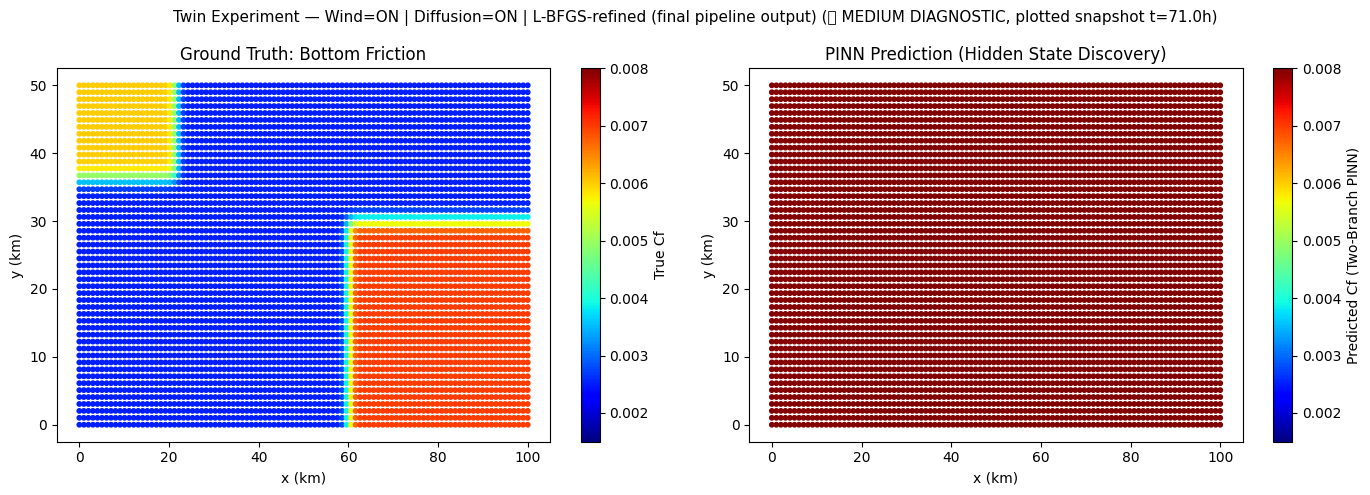


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.3408 meters
🚤 Long. Velocity (u) MAE: 1.1705 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.5724 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=9.86% , v=9.26% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00461 (102.47% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.1893 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = -0.023, corr(Cf_error, wind_y-pattern) = 0.451  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 102.47%, r(Cf) = 0.1893
    After L-BFGS-B: RMSE(Cf) = 102.47%, r(Cf) = 0.1901
    ✅ L-BFGS-

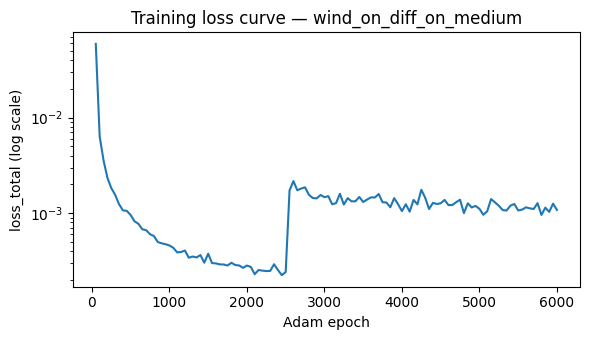


--- 📊 ABLATION COMPARISON — MEDIUM tier, diagnostic only, NOT for final §8.1 reporting ---
Scenario              RMSE(Cf) %     r(Cf)     MAE h     MAE u     MAE v  Corr(err,W)   Pass?   Time(s)  VRAM(MB)    Colloc
---------------------------------------------------------------------------------------------------------------------------
wind_off_diff_off_medium                                                                              — not run yet —
wind_on_diff_off_medium                                                                              — not run yet —
wind_on_diff_on_medium      102.47     0.190    0.2074    0.8606    0.4955        0.451      ⚠️      2504         —   decoup.


{'mae_h': np.float64(0.20736065981652443),
 'mae_u': np.float64(0.8606248146087346),
 'mae_v': np.float64(0.49551249204236547),
 'mae_u_pct_shallow': np.float64(7.756288725027012),
 'mae_v_pct_shallow': np.float64(8.319604479855657),
 'rmse_cf_pct': np.float64(102.47224968966795),
 'r_cf': np.float64(0.19005840990823877),
 'corr_wind_x': -0.02318337275257176,
 'corr_wind_y': 0.4505582759912302,
 'corr_wind_combined': np.float64(0.4505582759912302),
 'n_eval_snapshots': 60,
 'case': 'Wind=ON | Diffusion=ON',
 'mode': 'medium',
 'training_data_sparsified': True,
 'decoupled_collocation': True,
 'total_points_data': 57598,
 'total_points_physics': 360000,
 'training_seconds': 662.5557754039764,
 'lbfgs_seconds': 1841.5938529968262,
 'peak_vram_mb': None}

In [9]:
# %%
# Cell 8: Evaluate & Visualize (V17.7-corrected + RUN_MODE compatibility)
#
# 💥 CHANGES FROM THE VALIDATED Run A LINEAGE (all messaging/bookkeeping — no change to the
# evaluation math, the post-spin-up full-trajectory protocol, or the Adam-vs-L-BFGS comparison):
#   1. Mode display uses config.mode_label() instead of the SMOKE_TEST ternary.
#   2. `result['mode']` stores config.RUN_MODE directly (was the two-way smoke/full string).
#   3. The SMOKE_TEST-only "not valid for §8.1" warning block now has a third branch for
#      "medium", with wording appropriate to what that tier is actually for (see Cell 2 header).
#   4. 💥 The ablation-comparison table is now RUN_MODE-aware: canonical_tags are built with
#      the SAME suffix run_id() uses, so running all three scenarios under "medium" produces a
#      medium-tagged comparison table (clearly labeled as diagnostic-only), not silently
#      skipped as before (previously the table only ever matched bare, suffix-less tags, i.e.
#      "full" runs only). This directly supports ROADMAP.md Step 2's decision gate: compare
#      r(Cf) across the three medium-tier scenarios before committing to "full".
#   5. The `canonical_tags_guard` assertion is extended to cover "medium" as well as "smoke",
#      for symmetry — both are non-canonical tiers that must never silently land under a bare
#      (full-run) tag in the results file.
def _predict_chunked(model_apply, params, t_norm_flat, x_norm_flat, y_norm_flat, chunk_size=100_000):
    """Memory-bounded forward pass over a (possibly large) flat array of normalized (t,x,y)
    points. Returns denormalized (h, u, v, Cf) as numpy arrays."""
    vmap_apply = jax.vmap(model_apply, in_axes=(None, 0, 0, 0))
    n = t_norm_flat.shape[0]
    h_parts, u_parts, v_parts, cf_parts = [], [], [], []
    for lo in range(0, n, chunk_size):
        hi = min(lo + chunk_size, n)
        h_c, u_c, v_c, cf_c = vmap_apply(
            params,
            jnp.array(t_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(x_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(y_norm_flat[lo:hi], dtype=jnp.float64),
        )
        h_parts.append(np.array(h_c)); u_parts.append(np.array(u_c))
        v_parts.append(np.array(v_c)); cf_parts.append(np.array(cf_c))
    h_star = np.concatenate(h_parts); u_star = np.concatenate(u_parts)
    v_star = np.concatenate(v_parts); cf_star = np.concatenate(cf_parts)
    h_real, u_real, v_real, cf_real = utils_scaling.denormalize_outputs(h_star, u_star, v_star, cf_star)
    return np.array(h_real), np.array(u_real), np.array(v_real), np.array(cf_real)


def _pct_of_range(pred, true_at_eval, mask=None, range_source=None, range_mask=None):
    p, t = (pred[mask], true_at_eval[mask]) if mask is not None else (pred, true_at_eval)
    if p.size == 0:
        return np.nan
    if range_source is not None:
        rs = range_source[range_mask] if range_mask is not None else range_source
    else:
        rs = t
    rng = rs.max() - rs.min()
    return 100.0 * np.mean(np.abs(p - t)) / rng if rng > 0 else np.nan


def _evaluate_checkpoint(weights_path, model_apply, raw_data, label, case_label, do_plot):
    """Core evaluation for ONE saved checkpoint (Adam-only or L-BFGS-refined)."""
    try:
        with open(weights_path, 'rb') as f:
            params = pickle.load(f)
    except FileNotFoundError:
        return None

    x_raw, y_raw, t_raw = raw_data['x'], raw_data['y'], raw_data['t']
    h_true, u_true, v_true, Cf_true = raw_data['h'], raw_data['u'], raw_data['v'], raw_data['Cf_true']
    b_true_raw = raw_data['b_true']
    t_flat_all = t_raw.flatten()

    if 'spinup_duration_physical_s' in raw_data:
        spinup_s = float(raw_data['spinup_duration_physical_s'][0])
    else:
        spinup_s = config.SPINUP_DURATION_PHYSICAL
        print(f"    ℹ️ Dataset predates the stored spin-up field — falling back to "
              f"config.SPINUP_DURATION_PHYSICAL ({spinup_s/3600:.1f}h).")
    eval_mask = (t_flat_all >= spinup_s)
    if not np.any(eval_mask):
        print("    ⚠️ No saved snapshot is at/after the spin-up window — falling back to the "
              "full saved time series for evaluation.")
        eval_mask = np.ones_like(t_flat_all, dtype=bool)
    n_eval_snapshots = len(np.unique(t_flat_all[eval_mask]))

    x_eval, y_eval, t_eval = x_raw.flatten()[eval_mask], y_raw.flatten()[eval_mask], t_flat_all[eval_mask]
    x_norm, y_norm = utils_scaling.normalize_spatial(x_eval, y_eval)
    t_norm = utils_scaling.normalize_temporal(t_eval)

    h_pred, u_pred, v_pred, Cf_pred = _predict_chunked(model_apply, params, t_norm, x_norm, y_norm)

    h_true_flat = h_true.flatten()[eval_mask]
    u_true_flat = u_true.flatten()[eval_mask]
    v_true_flat = v_true.flatten()[eval_mask]
    b_true_flat = b_true_raw.flatten()[eval_mask]
    cf_true_flat = Cf_true.flatten()[eval_mask]

    mae_h = np.mean(np.abs(h_pred - h_true_flat))
    mae_u = np.mean(np.abs(u_pred - u_true_flat))
    mae_v = np.mean(np.abs(v_pred - v_true_flat))

    D_true_flat = h_true_flat - b_true_flat
    shallow_mask = D_true_flat < 40.0
    n_shallow = int(shallow_mask.sum())

    mae_u_pct_shallow = _pct_of_range(u_pred, u_true_flat, shallow_mask,
                                       range_source=u_true_flat, range_mask=None)
    mae_v_pct_shallow = _pct_of_range(v_pred, v_true_flat, shallow_mask,
                                       range_source=v_true_flat, range_mask=None)

    cf_range = cf_true_flat.max() - cf_true_flat.min()
    rmse_cf = np.sqrt(np.mean((Cf_pred - cf_true_flat) ** 2))
    rmse_cf_pct = 100.0 * rmse_cf / cf_range if cf_range > 0 else np.nan
    r_cf = np.corrcoef(Cf_pred, cf_true_flat)[0, 1]

    cf_error_flat = Cf_pred - cf_true_flat
    wind_pattern_x = np.sin(np.pi * y_eval / (config.L_REF / 2.0))
    wind_pattern_y = np.cos(np.pi * x_eval / config.L_REF)
    if np.std(cf_error_flat) > 0:
        corr_wind_x = float(np.corrcoef(cf_error_flat, wind_pattern_x)[0, 1])
        corr_wind_y = float(np.corrcoef(cf_error_flat, wind_pattern_y)[0, 1])
    else:
        corr_wind_x, corr_wind_y = np.nan, np.nan
    corr_wind_combined = (np.nanmax([abs(corr_wind_x), abs(corr_wind_y)])
                           if not (np.isnan(corr_wind_x) and np.isnan(corr_wind_y)) else np.nan)

    print(f"\n--- [{label}] ---")
    print(f"    Evaluation window: t >= {spinup_s/3600:.1f}h (post-spin-up), "
          f"{n_eval_snapshots} snapshot(s), {t_eval.shape[0]} total (t,x,y) rows")
    print(f"🌊 Water Level (h) MAE: {mae_h:.4f} meters")
    print(f"🚤 Long. Velocity (u) MAE: {mae_u:.4f} m/s (INFERRED - Hidden State)")
    print(f"🚤 Lat. Velocity (v) MAE: {mae_v:.4f} m/s (INFERRED - Hidden State)")
    if n_shallow > 0:
        print(f"🎯 H1a check (shallow water D<40m, n={n_shallow} pts, post-spin-up trajectory): "
              f"u={mae_u_pct_shallow:.2f}% , v={mae_v_pct_shallow:.2f}% of true velocity range "
              f"[success criterion: < 15%]")
    else:
        print("🎯 H1a check: no evaluation points with D<40m in this dataset — cannot assess.")
    print(f"🎯 Cf RMSE: {rmse_cf:.5f} ({rmse_cf_pct:.2f}% of true range) "
          f"[success criterion §8.1: < 5%]")
    print(f"🎯 Cf spatial correlation r = {r_cf:.4f} [success criterion §8.1: r > 0.95]")
    print(f"🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = {corr_wind_x:.3f}, "
          f"corr(Cf_error, wind_y-pattern) = {corr_wind_y:.3f}  "
          f"[high |corr| under Wind=OFF => spatial aliasing signature; "
          f"low |corr| under Wind=ON => aliasing resolved]")

    if do_plot:
        plot_row_mask = (t_eval == t_eval.max())
        plt.figure(figsize=(14, 5))
        plt.suptitle(f"Twin Experiment — {case_label} | {label} "
                     f"({config.mode_label()}, plotted snapshot t={t_eval.max()/3600:.1f}h)", fontsize=11)

        plt.subplot(1, 2, 1)
        sc1 = plt.scatter(x_eval[plot_row_mask]/1000, y_eval[plot_row_mask]/1000,
                           c=cf_true_flat[plot_row_mask], cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc1, label='True Cf')
        plt.title("Ground Truth: Bottom Friction")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.subplot(1, 2, 2)
        sc2 = plt.scatter(x_eval[plot_row_mask]/1000, y_eval[plot_row_mask]/1000,
                           c=Cf_pred[plot_row_mask], cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc2, label='Predicted Cf (Two-Branch PINN)')
        plt.title("PINN Prediction (Hidden State Discovery)")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.tight_layout()
        plt.show()

    return {"mae_h": mae_h, "mae_u": mae_u, "mae_v": mae_v,
            "mae_u_pct_shallow": mae_u_pct_shallow, "mae_v_pct_shallow": mae_v_pct_shallow,
            "rmse_cf_pct": rmse_cf_pct, "r_cf": r_cf,
            "corr_wind_x": corr_wind_x, "corr_wind_y": corr_wind_y,
            "corr_wind_combined": corr_wind_combined,
            "n_eval_snapshots": n_eval_snapshots}


def evaluate_model():
    print("\n--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery) ---")
    tag = config.scenario_tag()
    rid = config.run_id()
    case_label = f"Wind={'ON' if config.ENABLE_WIND else 'OFF'} | Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'}"
    print(f"    Ablation case: {case_label}  (tag: {tag}, mode: {config.mode_label()}, run_id: {rid})")

    # 💥 Extended to cover "medium" as well as "smoke" — both are non-canonical tiers whose
    # run_id() always carries a non-empty suffix by construction, so this can't actually fire,
    # but the assertion is made explicit/load-bearing rather than an unstated side effect.
    canonical_tags_guard = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]
    assert not (config.RUN_MODE in ("smoke", "medium") and rid in canonical_tags_guard), (
        f"RUN_MODE={config.RUN_MODE!r} but run_id '{rid}' matches a canonical full-run tag — "
        f"refusing to store this result, as it would corrupt the §8.1 ablation comparison."
    )

    model_init, model_apply = init_and_apply_model()
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'
    if not os.path.exists(lbfgs_path):
        print(f"❌ Weights not found at {lbfgs_path}. Run Cells 6 and 7 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.RUN_MODE settings first.")
        return

    raw_data = np.load(config.DATA_PATH)

    gen_version = str(raw_data['generator_version'][0]) if 'generator_version' in raw_data else None
    if gen_version is not None and 'upwind' not in gen_version:
        print(f"    ⚠️ WARNING: {config.DATA_PATH} was generated by tag {gen_version!r}, which "
              f"predates the upwind-advection stability fix. Regenerate via Cell 3 before "
              f"trusting §8.1 numbers.")

    sparsified = bool(raw_data['satellite_sparsification_enabled'][0]) if 'satellite_sparsification_enabled' in raw_data else None
    if sparsified is not None:
        print(f"    🛰️  Training DATA pool for this run was "
              f"{'SATELLITE-SPARSIFIED (stylized proxy)' if sparsified else 'DENSE (sparsification OFF)'}. "
              f"Evaluation below is always against the full dense grid regardless.")

    history_path_early = f'data/training_history_v17_{rid}.pkl'
    decoupled_collocation, total_points_data, total_points_physics = None, None, None
    if os.path.exists(history_path_early):
        with open(history_path_early, 'rb') as f:
            _hp_early = pickle.load(f)
        decoupled_collocation = _hp_early.get('decoupled_collocation')
        total_points_data = _hp_early.get('total_points_data')
        total_points_physics = _hp_early.get('total_points_physics')
        if decoupled_collocation is not None:
            print(f"    🧩 Physics-collocation design used in training: "
                  f"{'DECOUPLED, full-domain' if decoupled_collocation else 'COUPLED to satellite mask (comparison mode)'} "
                  f"| data points={total_points_data}, physics points={total_points_physics}")
        lbfgs_nit = _hp_early.get('lbfgs_nit')
        if lbfgs_nit is not None:
            print(f"    📐 L-BFGS-B convergence for this run_id: nit={lbfgs_nit}, "
                  f"nfev={_hp_early.get('lbfgs_nfev')}, converged={_hp_early.get('lbfgs_converged')}")

    result = _evaluate_checkpoint(lbfgs_path, model_apply, raw_data,
                                   label="L-BFGS-refined (final pipeline output)",
                                   case_label=case_label, do_plot=True)

    if getattr(config, 'EVALUATE_ADAM_STAGE_SEPARATELY', False):
        adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
        result_adam = _evaluate_checkpoint(adam_path, model_apply, raw_data,
                                            label="Adam-only (pre-L-BFGS)",
                                            case_label=case_label, do_plot=False)
        if result_adam is not None:
            d_rmse = result["rmse_cf_pct"] - result_adam["rmse_cf_pct"]
            print(f"\n--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---")
            print(f"    Adam-only:      RMSE(Cf) = {result_adam['rmse_cf_pct']:.2f}%, r(Cf) = {result_adam['r_cf']:.4f}")
            print(f"    After L-BFGS-B: RMSE(Cf) = {result['rmse_cf_pct']:.2f}%, r(Cf) = {result['r_cf']:.4f}")
            if d_rmse > 5.0:
                print(f"    🚨 L-BFGS-B WORSENED RMSE(Cf) by {d_rmse:.2f} percentage points — "
                      f"per the proposal's own decision rule, the ADAM-ONLY checkpoint should be "
                      f"treated as the primary reported result for this scenario.")
            elif d_rmse > 0:
                print(f"    ⚠️ L-BFGS-B mildly worsened RMSE(Cf) by {d_rmse:.2f} points.")
            else:
                print(f"    ✅ L-BFGS-B improved (or did not worsen) RMSE(Cf) by "
                      f"{abs(d_rmse):.2f} percentage points for this run.")
        else:
            print(f"\n    ℹ️ Adam-only weights not found at {adam_path} — skipping the VB13 "
                  f"before/after comparison for this run.")

    # 💥 Mode-aware caveat block (was: `if config.SMOKE_TEST:` only)
    if config.RUN_MODE == "smoke":
        print("\n   ℹ️ SMOKE tier: pipeline-health check only — NOT valid for §8.1 scenario "
              "comparison. Re-run with RUN_MODE='full' for numbers that count.")
    elif config.RUN_MODE == "medium":
        print("\n   ℹ️ MEDIUM tier: diagnostic only. Use this result to judge whether Cf "
              "recovery is trending toward the success criteria with more training budget — "
              "NOT as a final §8.1 number (dataset is still the 3-day smoke dataset). "
              "See ROADMAP.md Step 2 for the go/no-go decision this feeds.")

    history_path = f'data/training_history_v17_{rid}.pkl'
    training_seconds, peak_vram_mb, lbfgs_seconds, loss_history = None, None, None, None
    if os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            history_payload = pickle.load(f)
        training_seconds = history_payload.get('training_seconds')
        peak_vram_mb = history_payload.get('peak_vram_mb')
        lbfgs_seconds = history_payload.get('lbfgs_seconds')
        loss_history = history_payload.get('loss_history')
        decoupled_collocation = history_payload.get('decoupled_collocation', decoupled_collocation)
        total_points_data = history_payload.get('total_points_data', total_points_data)
        total_points_physics = history_payload.get('total_points_physics', total_points_physics)

        total_seconds = (training_seconds or 0) + (lbfgs_seconds or 0)
        vram_str = f"{peak_vram_mb:.0f} MB" if peak_vram_mb is not None else "unavailable"
        print(f"\n⏱️  Cost: Adam={training_seconds:.1f}s, L-BFGS={lbfgs_seconds:.1f}s, "
              f"total={total_seconds:.1f}s, peak VRAM={vram_str}"
              if training_seconds is not None and lbfgs_seconds is not None else
              "\n⏱️  Cost: partial data only in training-history file.")

        if loss_history:
            epochs_arr = [pt['epoch'] for pt in loss_history]
            loss_arr = [pt['loss_total'] for pt in loss_history]
            plt.figure(figsize=(6, 3.5))
            plt.plot(epochs_arr, loss_arr)
            plt.yscale('log')
            plt.xlabel("Adam epoch")
            plt.ylabel("loss_total (log scale)")
            plt.title(f"Training loss curve — {rid}")
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n⏱️  No training-history file found at {history_path}.")

    result.update({"case": case_label, "mode": config.RUN_MODE,  # 💥 was smoke/full ternary
                    "training_data_sparsified": sparsified,
                    "decoupled_collocation": decoupled_collocation,
                    "total_points_data": total_points_data,
                    "total_points_physics": total_points_physics,
                    "training_seconds": training_seconds, "lbfgs_seconds": lbfgs_seconds,
                    "peak_vram_mb": peak_vram_mb})

    results_path = 'data/ablation_results_v17.pkl'
    all_results = {}
    if os.path.exists(results_path):
        with open(results_path, 'rb') as f:
            all_results = pickle.load(f)
    all_results[rid] = result
    with open(results_path, 'wb') as f:
        pickle.dump(all_results, f)

    # 💥 RUN_MODE-aware ablation table: build canonical_tags with the SAME suffix run_id()
    # uses, so a "medium" three-scenario sweep gets its own comparison table (previously the
    # table only ever matched bare/full-run tags, silently skipping smoke AND medium tiers).
    base_tags = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]
    suffix = config._RUN_MODE_SUFFIX[config.RUN_MODE]
    canonical_tags = [f"{t}{suffix}" for t in base_tags]
    tier_note = {"smoke": " — SMOKE tier, pipeline-health only, NOT for §8.1",
                 "medium": " — MEDIUM tier, diagnostic only, NOT for final §8.1 reporting",
                 "full": " (§8.1, FULL RUNS)"}[config.RUN_MODE]

    if any(t in all_results for t in canonical_tags):
        print(f"\n--- 📊 ABLATION COMPARISON{tier_note} ---")
        header = (f"{'Scenario':<20}{'RMSE(Cf) %':>12}{'r(Cf)':>10}{'MAE h':>10}{'MAE u':>10}"
                  f"{'MAE v':>10}{'Corr(err,W)':>13}{'Pass?':>8}{'Time(s)':>10}{'VRAM(MB)':>10}{'Colloc':>10}")
        print(header)
        print("-" * len(header))
        for t in canonical_tags:
            if t in all_results:
                r = all_results[t]
                passed = "✅" if (r['rmse_cf_pct'] < 5.0 and r['r_cf'] > 0.95) else "⚠️"
                ts = r.get('training_seconds')
                ls = r.get('lbfgs_seconds')
                total_t = f"{(ts or 0)+(ls or 0):.0f}" if (ts is not None or ls is not None) else "—"
                vram = f"{r['peak_vram_mb']:.0f}" if r.get('peak_vram_mb') is not None else "—"
                cwc = r.get('corr_wind_combined')
                corr_str = f"{cwc:.3f}" if cwc is not None and not np.isnan(cwc) else "—"
                dc = r.get('decoupled_collocation')
                colloc_str = "decoup." if dc is True else ("coupled" if dc is False else "—")
                print(f"{t:<20}{r['rmse_cf_pct']:>12.2f}{r['r_cf']:>10.3f}"
                      f"{r['mae_h']:>10.4f}{r['mae_u']:>10.4f}{r['mae_v']:>10.4f}"
                      f"{corr_str:>13}{passed:>8}{total_t:>10}{vram:>10}{colloc_str:>10}")
            else:
                print(f"{t:<20}{'— not run yet —':>93}")

        colloc_flags = [all_results[t].get('decoupled_collocation') for t in canonical_tags if t in all_results]
        if len(set(colloc_flags)) > 1:
            print("\n   ⚠️ WARNING: the scenarios above were NOT all trained under the same "
                  "collocation design — this table is comparing different optimization problems.")

        if all(t in all_results for t in canonical_tags):
            delta = all_results[canonical_tags[0]]["rmse_cf_pct"] - all_results[canonical_tags[2]]["rmse_cf_pct"]
            if delta > 0:
                print(f"\n   🎯 Forcing-aliasing evidence (amplitude): RMSE(Cf) improved by {delta:.2f} "
                      f"percentage points from wind-off to the full model.")
            elif delta < 0:
                print(f"\n   ⚠️ RMSE(Cf) got WORSE by {abs(delta):.2f} percentage points from "
                      f"wind-off to the full model — investigate before final reporting.")
            else:
                print(f"\n   • RMSE(Cf) showed no change from wind-off to the full model.")

            corr_off = all_results[canonical_tags[0]].get("corr_wind_combined")
            corr_on = all_results[canonical_tags[2]].get("corr_wind_combined")
            if corr_off is not None and corr_on is not None and not (np.isnan(corr_off) or np.isnan(corr_on)):
                verdict = "Consistent with aliasing being resolved." if corr_on < corr_off else "Does NOT show the expected reduction — investigate."
                print(f"   🌀 Forcing-aliasing evidence (spatial fingerprint): |corr(err,wind)| = "
                      f"{corr_off:.3f} (wind-off) -> {corr_on:.3f} (full model). {verdict}")

    return result

evaluate_model()



################################################################################
# THREE-SCENARIO ABLATION SWEEP — RUN_MODE='medium' (🩺 MEDIUM DIAGNOSTIC)
################################################################################

▶ SCENARIO: wind=OFF, diffusion=OFF (tag: wind_off_diff_off, run_id: wind_off_diff_off_medium)

--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol) ---
    Ablation scenario: wind_off_diff_off (Wind=OFF, Diffusion=OFF)
    Mode: 🩺 MEDIUM DIAGNOSTIC | run_id: wind_off_diff_off_medium | data: data/twin_experiment_v17_smoketest.npz
    Training budget: epochs=6000, PHASE1_EPOCHS=2500, WARM_TRANSITION_EPOCHS=100
    Friction optimizer reset at Phase 2 boundary: ON (default)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    

Adam Phase:   0%|          | 0/6000 [00:00<?, ?it/s]

    🔄 epoch 2501: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (435.4s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_off_diff_off_medium.pkl  (run_id: wind_off_diff_off_medium)
   Saved -> data/training_history_v17_wind_off_diff_off_medium.pkl  (loss history + cost metadata for Cell 8 diagnostics)

--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning) ---
    Ablation scenario: wind_off_diff_off  (mode: 🩺 MEDIUM DIAGNOSTIC, run_id: wind_off_diff_off_medium) (Wind=OFF, Diffusion=OFF)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocati

/tmp/ipykernel_23/2608911301.py:162: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


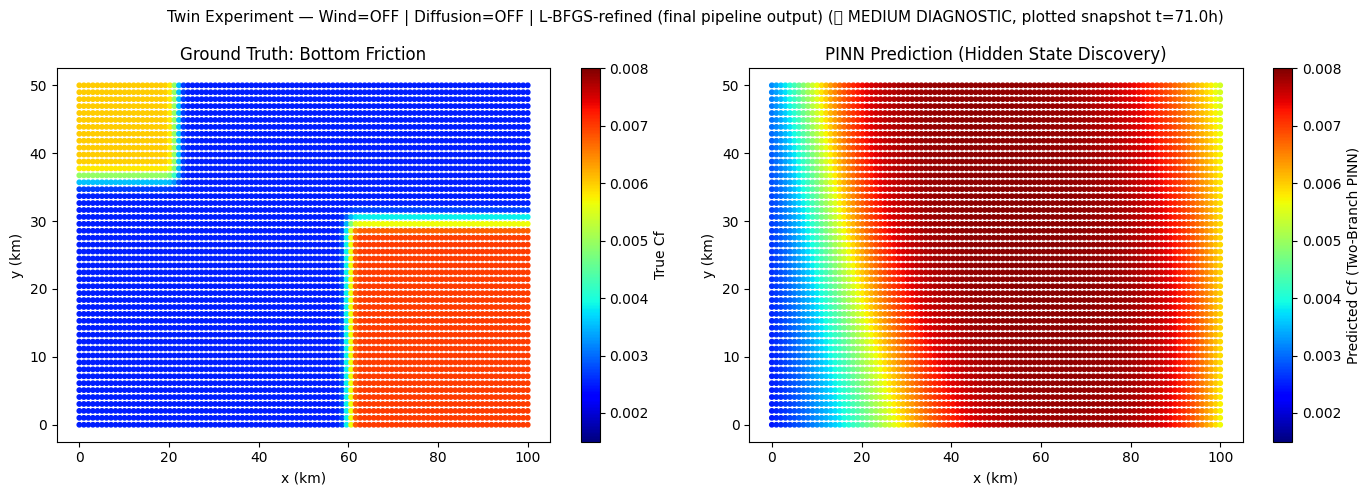


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.2423 meters
🚤 Long. Velocity (u) MAE: 0.9068 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.4698 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=8.01% , v=7.81% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00359 (79.70% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.0909 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = 0.012, corr(Cf_error, wind_y-pattern) = 0.042  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 79.70%, r(Cf) = 0.0909
    After L-BFGS-B: RMSE(Cf) = 84.03%, r(Cf) = 0.1400
    ⚠️ L-BFGS-B m

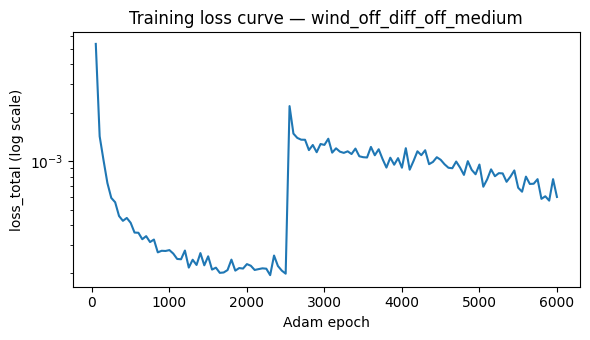


--- 📊 ABLATION COMPARISON — MEDIUM tier, diagnostic only, NOT for final §8.1 reporting ---
Scenario              RMSE(Cf) %     r(Cf)     MAE h     MAE u     MAE v  Corr(err,W)   Pass?   Time(s)  VRAM(MB)    Colloc
---------------------------------------------------------------------------------------------------------------------------
wind_off_diff_off_medium       84.03     0.140    0.1935    0.9431    0.4573        0.006      ⚠️      1489         —   decoup.
wind_on_diff_off_medium                                                                              — not run yet —
wind_on_diff_on_medium      102.47     0.190    0.2074    0.8606    0.4955        0.451      ⚠️      2504         —   decoup.

▶ SCENARIO: wind=ON, diffusion=OFF (tag: wind_on_diff_off, run_id: wind_on_diff_off_medium)

--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol) ---
    Ablation scenario: wind_on_diff_off (Wind=ON, Diffusion=OFF)
    Mode: 🩺 MEDIUM DIAGNOSTIC | run_id: wind_on_diff_

Adam Phase:   0%|          | 0/6000 [00:00<?, ?it/s]

    🔄 epoch 2501: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (431.4s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_on_diff_off_medium.pkl  (run_id: wind_on_diff_off_medium)
   Saved -> data/training_history_v17_wind_on_diff_off_medium.pkl  (loss history + cost metadata for Cell 8 diagnostics)

--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning) ---
    Ablation scenario: wind_on_diff_off  (mode: 🩺 MEDIUM DIAGNOSTIC, run_id: wind_on_diff_off_medium) (Wind=ON, Diffusion=OFF)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocation poi

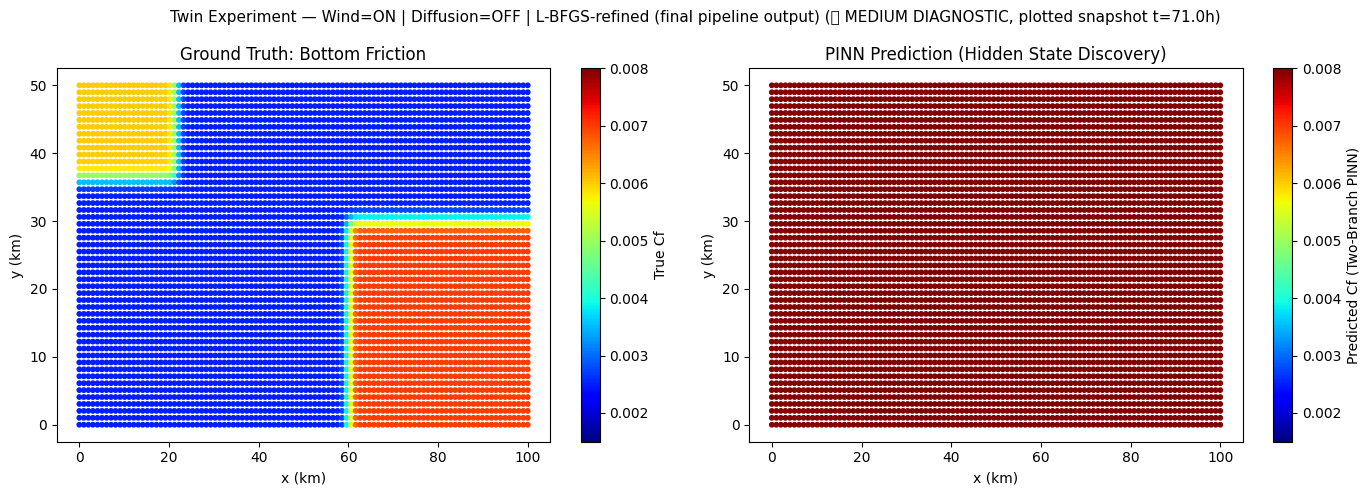


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.3407 meters
🚤 Long. Velocity (u) MAE: 1.1712 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.5730 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=9.87% , v=9.26% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00461 (102.47% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.1909 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = -0.023, corr(Cf_error, wind_y-pattern) = 0.451  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 102.47%, r(Cf) = 0.1909
    After L-BFGS-B: RMSE(Cf) = 102.47%, r(Cf) = 0.1917
    ✅ L-BFGS-

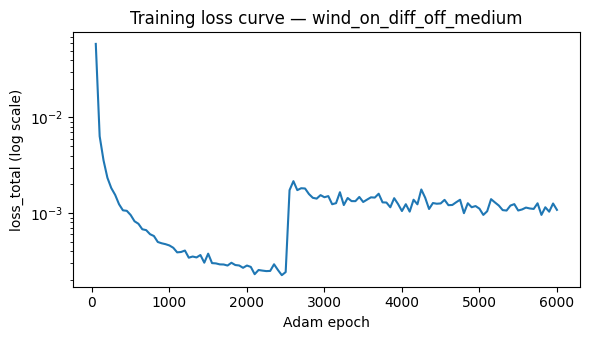


--- 📊 ABLATION COMPARISON — MEDIUM tier, diagnostic only, NOT for final §8.1 reporting ---
Scenario              RMSE(Cf) %     r(Cf)     MAE h     MAE u     MAE v  Corr(err,W)   Pass?   Time(s)  VRAM(MB)    Colloc
---------------------------------------------------------------------------------------------------------------------------
wind_off_diff_off_medium       84.03     0.140    0.1935    0.9431    0.4573        0.006      ⚠️      1489         —   decoup.
wind_on_diff_off_medium      102.47     0.192    0.2083    0.8673    0.4931        0.450      ⚠️      1481         —   decoup.
wind_on_diff_on_medium      102.47     0.190    0.2074    0.8606    0.4955        0.451      ⚠️      2504         —   decoup.

   ⚠️ RMSE(Cf) got WORSE by 18.44 percentage points from wind-off to the full model — investigate before final reporting.
   🌀 Forcing-aliasing evidence (spatial fingerprint): |corr(err,wind)| = 0.006 (wind-off) -> 0.451 (full model). Does NOT show the expected reduction — inve

Adam Phase:   0%|          | 0/6000 [00:00<?, ?it/s]

    🔄 epoch 2501: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (664.6s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_on_diff_on_medium.pkl  (run_id: wind_on_diff_on_medium)
   Saved -> data/training_history_v17_wind_on_diff_on_medium.pkl  (loss history + cost metadata for Cell 8 diagnostics)

--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning) ---
    Ablation scenario: wind_on_diff_on  (mode: 🩺 MEDIUM DIAGNOSTIC, run_id: wind_on_diff_on_medium) (Wind=ON, Diffusion=ON)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocation points (f

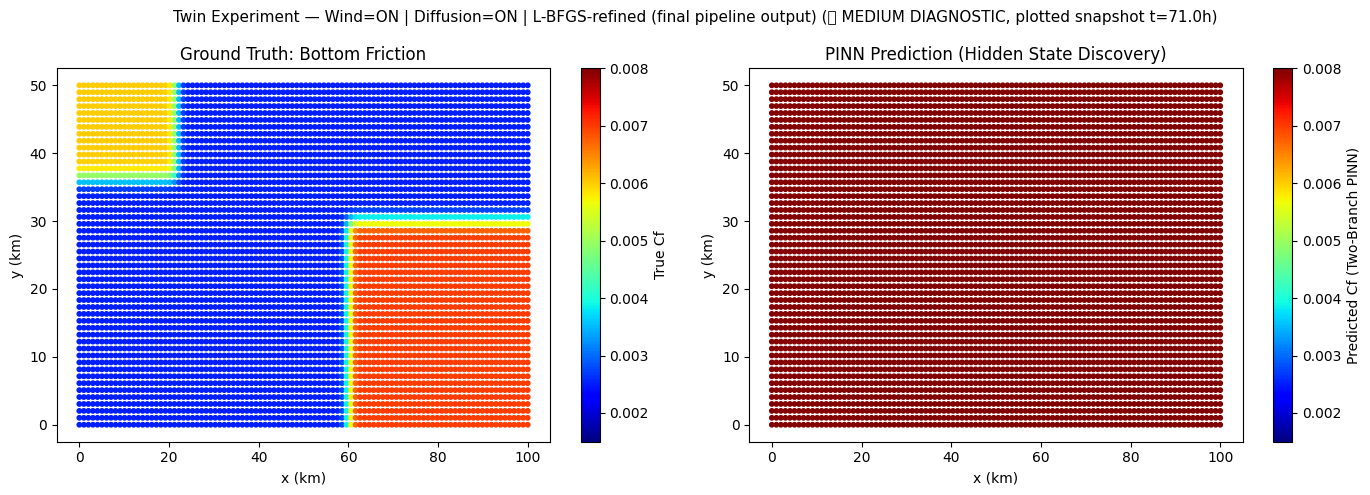


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t >= 12.0h (post-spin-up), 60 snapshot(s), 300000 total (t,x,y) rows
🌊 Water Level (h) MAE: 0.3408 meters
🚤 Long. Velocity (u) MAE: 1.1705 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.5724 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=124175 pts, post-spin-up trajectory): u=9.86% , v=9.26% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00461 (102.47% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.1893 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = -0.023, corr(Cf_error, wind_y-pattern) = 0.451  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 102.47%, r(Cf) = 0.1893
    After L-BFGS-B: RMSE(Cf) = 102.47%, r(Cf) = 0.1901
    ✅ L-BFGS-

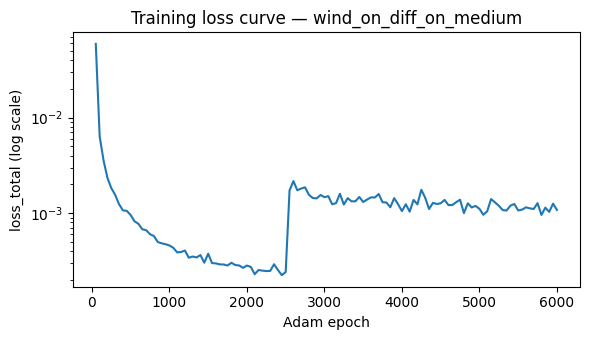


--- 📊 ABLATION COMPARISON — MEDIUM tier, diagnostic only, NOT for final §8.1 reporting ---
Scenario              RMSE(Cf) %     r(Cf)     MAE h     MAE u     MAE v  Corr(err,W)   Pass?   Time(s)  VRAM(MB)    Colloc
---------------------------------------------------------------------------------------------------------------------------
wind_off_diff_off_medium       84.03     0.140    0.1935    0.9431    0.4573        0.006      ⚠️      1489         —   decoup.
wind_on_diff_off_medium      102.47     0.192    0.2083    0.8673    0.4931        0.450      ⚠️      1481         —   decoup.
wind_on_diff_on_medium      102.47     0.190    0.2074    0.8606    0.4955        0.451      ⚠️      2501         —   decoup.

   ⚠️ RMSE(Cf) got WORSE by 18.44 percentage points from wind-off to the full model — investigate before final reporting.
   🌀 Forcing-aliasing evidence (spatial fingerprint): |corr(err,wind)| = 0.006 (wind-off) -> 0.451 (full model). Does NOT show the expected reduction — inve

In [10]:
# %%
# Cell 9 (NEW, optional): Three-Scenario Ablation Driver
#
# Runs all three §8.1 ablation scenarios back-to-back UNDER THE CURRENT config.RUN_MODE — set
# RUN_MODE in Cell 2 first ("medium" for the diagnostic sweep in ROADMAP.md Step 1-2, "full" for
# the final run in Step 4), then run this cell instead of manually re-running Cells 6/7/8 three
# times with ENABLE_WIND/ENABLE_DIFFUSION toggled by hand.
#
# Must run AFTER Cells 1-5 (imports, config, data generation, dataset class, physics/model
# definitions) have executed once. Does NOT re-run Cell 3 between scenarios — all three
# scenarios train against the SAME twin-experiment dataset, which is exactly what §8.1's
# controlled comparison requires (only ENABLE_WIND/ENABLE_DIFFUSION vary between scenarios).
#
# After all three finish, Cell 8's own ABLATION COMPARISON table (printed by the last
# evaluate_model() call) already summarizes them — re-run evaluate_model() once more standalone
# if you want to reprint that table without re-training anything.
SCENARIOS = [
    (False, False),  # wind_off_diff_off — isolates pure forcing-aliasing bias
    (True,  False),  # wind_on_diff_off
    (True,  True),   # wind_on_diff_on  — full model
]

print(f"\n{'#'*80}\n# THREE-SCENARIO ABLATION SWEEP — RUN_MODE={config.RUN_MODE!r} ({config.mode_label()})\n{'#'*80}")

_sweep_t_start = time.time()
for wind_on, diff_on in SCENARIOS:
    config.ENABLE_WIND = wind_on
    config.ENABLE_DIFFUSION = diff_on
    print(f"\n{'='*80}\n▶ SCENARIO: wind={'ON' if wind_on else 'OFF'}, diffusion={'ON' if diff_on else 'OFF'} "
          f"(tag: {config.scenario_tag()}, run_id: {config.run_id()})\n{'='*80}")
    train_augmented_pinn()
    train_lbfgs_scipy()
    evaluate_model()

_sweep_seconds = time.time() - _sweep_t_start
print(f"\n✅ All {len(SCENARIOS)} scenarios complete for RUN_MODE={config.RUN_MODE!r} "
      f"(total wall time: {_sweep_seconds/60:.1f} min). See the ABLATION COMPARISON table "
      f"printed above for the cross-scenario summary that drives the ROADMAP.md decision gate.")
